In [1]:
#import scarches as sca
#import torch
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os
import time
import pickle
from itertools import chain
import itertools
from tqdm.auto import tqdm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

proc_dir='../../xenium_data/processed_data/baysor_processed_output'

# FUNCTIONS

In [39]:
##### =========================
## LOAD THE NUMBER OF TRANSCRIPTS OUTPUT BY BAYSOR SEGMENTATION FOR EACH SAMPLE
def load_num_of_segm_transcripts(scale_param,avg_assignment_conf_thr):

    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df
    
    
    
    seg_transcr_dict={}
    
    ## Create panel_sample_names
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    panels=['Panel1','Panel2']
    pat_nums=['P1','P2','P3','P4']#'P5','P6','P7','P8','P9','P10','P11','P12']
    conditions=['D','H']
    panel_sample_names_1=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panels=['Panel1','Panel2']
    pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12'] 
    conditions=['D']
    
    panel_sample_names_2=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panel_sample_names = panel_sample_names_1 + panel_sample_names_2
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    auc_metric='high_confidence_weighted_auc'
    #avg_assignment_conf_thr=0.75
    overwrite_anndata=True
    
    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    #scale_param='10'
    #avg_assignment_conf_thr=0.75
        
    
    for panel_sample_name in panel_sample_names[:]:
    
        ## Load the all the baysor models available for given sample and select only methods that contain 'segm_method'
        #  i.e. either all methods containing '10x' or all methods containing 'scale_5' (as an example)
        baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
    
    
            
        bays_model_dirlist=[filename for filename in os.listdir(baysor_out_fold) if os.path.isdir(os.path.join(baysor_out_fold,filename))]
    
                
        ## Extract name of best baysor model to use for the sample
        best_model=best_model_dict[auc_metric][scale_param].loc[panel_sample_name,avg_assignment_conf_thr]
        bays_model_name='assignments_'+best_model
    
        proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor',panel_sample_name,bays_model_name)
        fpath=os.path.join(proc_dir,f"{panel_sample_name}_{bays_model_name}.h5ad")
        if os.path.exists(fpath) and overwrite_anndata==False:
            logging.info(f'{panel_sample_name} - {bays_model_name} already exists, skipping to next sample\n')
            next
        if not os.path.exists(fpath) or overwrite_anndata==True:    
    
    
            ##===== LOAD BACKGROUND + FOREGROUND ADATA INTO DICTIONARY + EXTRACT CELL ASSIGNMENTS FOR TRANSCRIPTS FOR EACH MODEL =======##
            #logging.info(f'For sample {panel_sample_name} loading {bays_model_name} \n')
        
            ##===== READ NECESSARY INPUT FILES =======##
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,usecols=[0,1])
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue
            #print(panel_sample_name,seg.shape[0])
            seg_transcr_dict[panel_sample_name]=seg.shape[0]
            del seg

    return seg_transcr_dict


### =============================
## LOAD THE NUMBER OF TRANSCRIPTS OUTPUT BY BAYSOR SEGMENTATION FOR EACH SAMPLE
def return_best_model_dict():
    
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:1]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df

    return best_model_dict

# LOAD DATA INTO DICT

In [3]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

proc_dir='../../xenium_data/processed_data/baysor_processed_output'
scale_param='10'
avg_assignment_conf_thr=0.75

cellt_name_refine_dict={'final_low_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'Mac_S1008+':'Mac_S100A8hi',
                                                    r'\+': '',
                                                   r'Mac_ITGAX_?':'Mac_ITGAXhi',
                                                   r'\?': '',},
                        
                        'final_high_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'\+': '',
                                                    r'Lymphocyte':'Inflammatory_mixed_cell',
                                                    r'Macrophage/Neutrophil':'Macrophage'},
                        
                        'final_low_level_celltype_substates':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                              r'Mac_S1008+':'Mac_S100A8hi',
                                                             r'\+': ''},
                        
                        'condition':{'D':'Plaque',
                                     'H':'Control'},
                        
                        'original_sample':{'_D':'_Pl',
                                           '_H':'_Ctrl'},
                       }




adata_dict_={}
scale_params=['5','10','15','5|10|15'][:-1]

for scale_param in scale_params:
    adata_dict_[scale_param]={}

    for leg_loc in ["on data",'right margin'][1:]:
    
        for panel in ['Panel1','Panel2'][:]:

    
            ## Save batch corrected data
            #fn=os.path.join(proc_dir,f'filtered_batch_corr_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            #fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            try:
                fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_.h5ad')
                adata=sc.read_h5ad(fn)
            except FileNotFoundError:
                continue
                
        
            adata.obsm["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()
            #adata.uns["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()
        
            ## Load Sample regions to .obs
            fn=os.path.join(proc_dir,f'filtered_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            adata_=sc.read_h5ad(fn)
            adata.obs['sample_region']=adata_.obs.loc[adata.obs.index,'sample_region'].values
            adata.obs['cell_mask_area_um2']=adata_.obs.loc[adata.obs.index,'cell_mask_area_um2'].values
            #adata.layers['norm_by_area']=adata_.layers['norm_by_area']
            del adata_
    
            for obs_coln in cellt_name_refine_dict.keys():
                if obs_coln in adata.obs.columns and scale_param not in ['10','5']:
                    print(scale_param,panel,obs_coln)
                    adata.obs[obs_coln] = adata.obs[obs_coln].astype(str)
                    adata.obs[obs_coln]=adata.obs[obs_coln].replace(cellt_name_refine_dict[obs_coln],regex=True)
    
            adata_dict_[scale_param][panel]=adata

15 Panel1 final_low_level_celltype
15 Panel1 final_high_level_celltype
15 Panel1 condition
15 Panel1 original_sample
15 Panel2 final_low_level_celltype
15 Panel2 final_high_level_celltype
15 Panel2 condition
15 Panel2 original_sample


# Suppl.FIG. B - PLOT CELLTYPE UMAPS PER SCALE PARAMETER

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

proc_dir='../../xenium_data/processed_data/baysor_processed_output'
scale_param='10'
avg_assignment_conf_thr=0.75

cellt_name_refine_dict={'final_low_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'Mac_S1008+':'Mac_S100A8hi',
                                                    r'\+': '',
                                                   r'Mac_ITGAX_?':'Mac_ITGAXhi',
                                                   r'\?': '',},
                        
                        'final_high_level_celltype':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                    r'\+': '',
                                                    r'Lymphocyte':'Inflammatory_mixed_cell',
                                                    r'Macrophage/Neutrophil':'Macrophage'},
                        
                        'final_low_level_celltype_substates':{'B2-cell_\\?':'Inflammatory_mixed_cell',
                                                              r'Mac_S1008+':'Mac_S100A8hi',
                                                             r'\+': ''},
                        
                        'condition':{'D':'Plaque',
                                     'H':'Control'},
                        
                        'original_sample':{'_D':'_Pl',
                                           '_H':'_Ctrl'},
                       }




adata_dict_={}
scale_params=['5','10','15','5|10|15'][:-1]

for scale_param in scale_params:
    adata_dict_[scale_param]={}

    for leg_loc in ["on data",'right margin'][1:]:
    
        for panel in ['Panel1','Panel2'][:]:

    
            ## Save batch corrected data
            #fn=os.path.join(proc_dir,f'filtered_batch_corr_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            #fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            try:
                fn=os.path.join(proc_dir,f'filtered_batch_corr_annotated_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_.h5ad')
                adata=sc.read_h5ad(fn)
            except FileNotFoundError:
                continue
                
        
            adata.obsm["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()
            #adata.uns["spatial"] = adata.obs[["x", "y"]].copy().to_numpy()
        
            ## Load Sample regions to .obs
            fn=os.path.join(proc_dir,f'filtered_{panel}_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}.h5ad')
            adata_=sc.read_h5ad(fn)
            adata.obs['sample_region']=adata_.obs.loc[adata.obs.index,'sample_region'].values
            adata.obs['cell_mask_area_um2']=adata_.obs.loc[adata.obs.index,'cell_mask_area_um2'].values
            #adata.layers['norm_by_area']=adata_.layers['norm_by_area']
            del adata_
    
            for obs_coln in cellt_name_refine_dict.keys():
                if obs_coln in adata.obs.columns and scale_param not in ['10','5']:
                    print(scale_param,panel,obs_coln)
                    adata.obs[obs_coln] = adata.obs[obs_coln].astype(str)
                    adata.obs[obs_coln]=adata.obs[obs_coln].replace(cellt_name_refine_dict[obs_coln],regex=True)
    
            adata_dict_[scale_param][panel]=adata




            ### Save source data for plot               
            umap_coords_df=pd.DataFrame(data=adata.obsm['X_umap'],
                                         columns=['UMAP1','UMAP2'],
                                         index=adata.obs_names)    
            source_df=pd.concat([umap_coords_df,adata.obs.loc[umap_coords_df.index,['final_high_level_celltype','final_low_level_celltype']]],axis=1)           
            source_df.index.name='Cell_ID'

            
            source_dir=os.path.join(proc_dir,'source_data','first_revision')
            os.makedirs(source_dir,exist_ok=True)

            if scale_param=='5' and panel=='Panel1':                        
                fn=os.path.join(source_dir,'Suppl_Fig37A_B.xlsx')
                #source_df.to_excel(fn)
            
            if scale_param=='10' and panel=='Panel1':                             
                fn=os.path.join(source_dir,'Suppl_Fig37C_D.xlsx')
                #source_df.to_excel(fn)

            if scale_param=='15' and panel=='Panel1':                       
                fn=os.path.join(source_dir,'Suppl_Fig37E_F.xlsx')
                #source_df.to_excel(fn)
            
            if scale_param=='5' and panel=='Panel2':                        
                fn=os.path.join(source_dir,'Suppl_Fig38A_B.xlsx')
                #source_df.to_excel(fn)
            
            if scale_param=='10' and panel=='Panel2':                             
                fn=os.path.join(source_dir,'Suppl_Fig38C_D.xlsx')
                #source_df.to_excel(fn)

            if scale_param=='15' and panel=='Panel2':                       
                fn=os.path.join(source_dir,'Suppl_Fig38E_F.xlsx')
                #source_df.to_excel(fn)

            
    
           
            cell_cols=['final_high_level_celltype','final_low_level_celltype'][:]

            num_of_plots=len(cell_cols)*len(scale_params)
            ncols=2
            nrows=int(np.ceil(num_of_plots/ncols))
            fig=plt.figure(figsize=(ncols*8,nrows*6.5))
            
            for n,col in enumerate(cell_cols[:]):
            #for col in (cell_cols[:]):

                width_adj_param=7
                height_adj_param=5.5
                heigh_width_ratio=(height_adj_param/width_adj_param)
        
          
            
                #fig,ax=plt.subplots(1,1,figsize=(ncols*width_adj_param,nrows*height_adj_param))
        
                ax=fig.add_subplot(nrows,ncols,n+1) 
        
                #suptitle='-'.join([panel,param_set_string,f'\ncells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}'])
                

                #fig.suptitle(suptitle,fontweight='bold',fontsize=10,y=0.93,x=0.5)
                #leg_loc='right margin'

        
                #if col in cell_cols:
                #    leg_loc="on data"
                
                sc.pl.umap(adata, color=col,show=False,
                           ax=ax,
                           size=3.5,
                           #vmin=0.5,
                           #vmax=1,
                           vmin='p1',
                           vmax='p99',
                           legend_fontsize=9,
                           legend_fontweight='semibold',
                           legend_loc=leg_loc)

                ax_title=f"Xenium - {col.split('final_')[-1].replace('_',' ').capitalize()} \nBaysor scale parameter: {scale_param}"
                ax.set_title(ax_title,fontweight='bold',fontsize=10,y=0.97)
    
                            
                #plt.box(False)
                #ax.set_xlabel('UMAP1',fontsize=12, fontweight='bold',x=0.15*(height_adj_param/width_adj_param))
                #ax.set_ylabel('UMAP2',fontsize=12, fontweight='bold',y=0.15)
                ax.set_xlabel(None)
                ax.set_ylabel(None)
        
                 # Adding small x and y axes in the lower-left corner
                ax.spines['bottom'].set_color('black')
                ax.spines['bottom'].set_linewidth(1)
                ax.spines['left'].set_color('black')
                ax.spines['left'].set_linewidth(1)
                
                # Hide top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
        
                # Set custom limits for small axes
                # Set custom bounds for equally long axes
                x_axis_length = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.2  # Define axis length
                x_axis_offset=x_axis_length*0.1
                y_axis_length = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.2 * (1/heigh_width_ratio)  # Define axis length
                y_axis_offset=y_axis_length*0.1
                
                x_start, x_end = ax.get_xlim()[0]+x_axis_offset, ax.get_xlim()[0] + x_axis_length
                y_start, y_end = ax.get_ylim()[0]+y_axis_offset, ax.get_ylim()[0] + y_axis_length
                
                ax.spines['bottom'].set_bounds(x_start, x_end)
                ax.spines['left'].set_bounds(y_start, y_end)
                
                # Add arrows to axis tips        
                arrow_style = mpatches.ArrowStyle("-|>", head_length=0.5, head_width=0.2)
                ax.annotate('', xy=(x_end+0.5, ax.get_ylim()[0]), xytext=(x_end - 0.001 * x_axis_length, ax.get_ylim()[0]), 
                            arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
                ax.annotate('', xy=(ax.get_xlim()[0], y_end+0.5), xytext=(ax.get_xlim()[0], y_end - 0.001 * y_axis_length), 
                            arrowprops=dict(arrowstyle=arrow_style, color='black', lw=1))
        
        
                ## Add label titles
                ax_label_offset=0.4
                ax.text((x_start+x_end)/2, ax.get_ylim()[0]-ax_label_offset,'UMAP1',weight='bold',fontsize=12,
                        horizontalalignment='center',verticalalignment='center')
                ax.text(ax.get_xlim()[0]-ax_label_offset, (y_start+y_end)/2, 'UMAP2',weight='bold',fontsize=12, 
                        horizontalalignment='center',rotation_mode='anchor',rotation=90,
                        verticalalignment='center')
    
    
    
                # If there is a legend, remove it and add a customized one
                if leg_loc=='right margin':
                    
                    ax.legend_.remove()
    
                    
                    legend_handles=[Line2D([0],[0],
                                           marker="o",
                                           color=c,
                                           lw=0,label=l,
                                           markerfacecolor=c,
                                           markersize=7,)                                    
                                            for l, c in zip(list(adata.obs[col].cat.categories), adata.uns[f"{col}_colors"])]

                                    
                    # Make new Legend
                    l1 = ax.legend(handles=legend_handles,                
                                   frameon=False,
                                   ncols=1,
                                   loc='center',
                                   #loc='best',
                                   fontsize=11,
                                   markerscale=1.15,
                                   handletextpad=0.05,                                   
                                   bbox_to_anchor=(1.15, 0.5),
                                   #title="Cell type",
                                  )
                                                
                
                #plt.tight_layout(w_pad=0.98)
                plt.subplots_adjust(wspace=0.4)
                
            ## SAvefig    
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            os.makedirs(os.path.join(proc_dir,'figure_plots','SFigB','celltype_UMAPS'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','SFigB','celltype_UMAPS',
                            f'{panel}_{scale_param}_legend_{leg_loc}_UMAP.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')
    
            '''
            ##### SAVE LEGEND FOR CELL TYPE AND REGIONS AS SEPARATE FIGURES
            if leg_loc=='right margin':
                # Create a new figure for the legend
                legend_fig, legend_ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
                legend_ax.axis('off')  # Turn off the axis for a clean legend
                l1 = legend_ax.legend(handles=legend_handles,                
                                       frameon=False,
                                       ncols=1,
                                       markerscale=2,
                                       fontsize=25,
                                       loc='center',
                                       #bbox_to_anchor=(1, 0.75),
                                       #title="Cell type",
                                            )

                os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','UMAP'),exist_ok=True)
                fn=os.path.join(proc_dir,'figure_plots','Fig2','UMAP',f'{panel}_{col}_legend_{leg_loc}_UMAP_legend.png')
                #legend_fig.savefig(fn, dpi=300, bbox_inches='tight')
            '''

# DEPRECATED - EXTRACT AVERAGE EXPRESSION SIGNATURE PER CELL TYPE

In [ ]:

expr_dict={}

for panel in ['Panel1','Panel2'][:1]:
    expr_dict[panel]={}

#for scale_param in ['10','15']:
    a10 = adata_dict_['10'][panel]
    a15 = adata_dict_['15'][panel]
    a5_10_15 = adata_dict_['5|10|15'][panel]

    a10_c=(a10.obs['final_low_level_celltype'].value_counts(dropna=False))
    a15_c=(a15.obs['final_low_level_celltype'].value_counts(dropna=False))
    a5_10_15_c=(a5_10_15.obs['final_low_level_celltype'].value_counts(dropna=False))

    celltp_counts=pd.concat([a10_c,a15_c,a5_10_15_c],axis=1)
    celltp_counts.columns=['10','15','5|10|15']

    celltp_counts['10-15_diff']=celltp_counts['10']-  celltp_counts['15']
    print(celltp_counts)

    l,k,m,n=[],[],[],[]

    for cellt in celltp_counts.index:
        #print(cellt)
        a10_ct=a10[a10.obs['final_low_level_celltype']==cellt,:].copy()
        a15_ct=a15[a15.obs['final_low_level_celltype']==cellt,:].copy()
        a5_10_15_ct=a5_10_15[a5_10_15.obs['final_low_level_celltype']==cellt,:].copy()

        a10_expr = a10_ct.layers['norm_by_area_all'].A.mean(axis=0)
        a15_expr = a15_ct.layers['norm_by_area_all'].A.mean(axis=0)
        a5_10_15_expr = a5_10_15_ct.layers['norm_by_area_all'].A.mean(axis=0)

        a10_expr = a10_ct.layers['raw_counts'].A.mean(axis=0)
        a15_expr = a15_ct.layers['raw_counts'].A.mean(axis=0)
        a5_10_15_expr = a5_10_15_ct.layers['raw_counts'].A.mean(axis=0)

        expr_diff = pd.DataFrame(data=(a10_expr - a15_expr),index=a10.var['HGNC'])
        expr_diff.columns=[cellt]

        a10_expr_df = pd.DataFrame(data=(a10_expr),index=a10.var['HGNC'])
        a10_expr_df.columns=[cellt]

        a15_expr_df = pd.DataFrame(data=(a15_expr),index=a15.var['HGNC'])
        a15_expr_df.columns=[cellt]

        a5_10_15_expr_df = pd.DataFrame(data=(a5_10_15_expr),index=a5_10_15.var['HGNC'])
        a5_10_15_expr_df.columns=[cellt]

        #expr_diff.sort
        l.append(expr_diff)
        k.append(a10_expr_df)
        m.append(a15_expr_df)
        n.append(a5_10_15_expr_df)



    expr_diff_df=pd.concat(l,axis=1)
    a10_expr_df=pd.concat(k,axis=1)
    a15_expr_df=pd.concat(m,axis=1)
    a5_10_15_expr_df=pd.concat(n,axis=1)
    
    expr_dict[panel]['a10_expr_df']=a10_expr_df
    expr_dict[panel]['a15_expr_df']=a15_expr_df
    expr_dict[panel]['a5_10_15_expr_df']=a15_expr_df
    expr_dict[panel]['10-15_expr_diff']=expr_diff_df


# ADJUST SEGMENTATION QC DATA 
- Xenium reader picked up lot of noise outside os sample area ==> exclude these transcripts from QC metric calculation

## Extract transcripts that are localised on the area of the sample

In [ ]:
from shapely.geometry import Point, Polygon,MultiPolygon
from matplotlib import path as mpath
import shapely


## Create panel_sample_names
data_dir="../../xenium_data/"#processed_data/cell_segmentation"
panels=['Panel1','Panel2']
pat_nums=['P1','P2','P3','P4']#'P5','P6','P7','P8','P9','P10','P11','P12']
conditions=['D','H']
panel_sample_names_1=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]

panels=['Panel1','Panel2']
pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12'] 
conditions=['D']

panel_sample_names_2=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]

panel_sample_names = panel_sample_names_1 + panel_sample_names_2
#panel_sample_names=['Panel2_P6_D']

## Determine which AUC metric to use for selection of best model 
#  (to check on which to select, check 'best_model_dict's ' elements
auc_metric='high_confidence_weighted_auc'
avg_assignment_conf_thr=0.75
overwrite_anndata=True
    

#seg_transcr_dict,noise_pct_dict,hq_transcript_dict={},{},{}



for panel_sample_name in panel_sample_names[:]:
    noise_dict={}
    #seg_transcr_dict[panel_sample_name]={}
    #noise_pct_dict[panel_sample_name]={}
    #hq_transcript_dict[panel_sample_name]={}

    ## Load the all the baysor models available for given sample and select only methods that contain 'segm_method'
    #  i.e. either all methods containing '10x' or all methods containing 'scale_5' (as an example)
    baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
        
    bays_model_dirlist=[filename for filename in os.listdir(baysor_out_fold) if os.path.isdir(os.path.join(baysor_out_fold,filename))]


    print(panel_sample_name)

            
    proc_dir="../../xenium_data/processed_data/baysor_processed_output"
    #orig_sample = '_'.join(panel_sample_name.split('_')[1:])
    orig_sample = panel_sample_name
    
    ## Replace 
    replacements = {'_H':'_Ctrl','_D':'_Pl'}
    for old, new in replacements.items():
        if old in orig_sample:
            orig_sample_ = orig_sample.replace(old, new)
        
    filename=f'{proc_dir}/{orig_sample}_reg_area_dict.pickle'
    with open(filename, 'rb') as handle:
        reg_area_dict=pickle.load(handle)
        print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
    
    ## Just loop over one segmentation file, as the transcripts are indentical in all segmentation results, 
    #. here we just want to assign the transcripts to region and sample areas
    for bays_model_name in bays_model_dirlist[:1]:
        print(bays_model_name)
        
        panel = panel_sample_name.split('_')[0]
        scale_param=bays_model_name.split('scale')[-1].split('_')[1]

        adata=adata_dict_[scale_param][panel]
        adata_sample=adata[adata.obs['original_sample']==orig_sample_,:].copy()

    
        ## LOAD BAYSOR SEGMENTATION CSV
        fpath=os.path.join(proc_dir,f"{panel_sample_name}_{bays_model_name}.h5ad")
        if os.path.exists(fpath) and overwrite_anndata==False:
            logging.info(f'{panel_sample_name} - {bays_model_name} already exists, skipping to next sample\n')
            next
        if not os.path.exists(fpath) or overwrite_anndata==True:    
    
    
            ##===== LOAD BACKGROUND + FOREGROUND ADATA INTO DICTIONARY + EXTRACT CELL ASSIGNMENTS FOR TRANSCRIPTS FOR EACH MODEL =======##
            #logging.info(f'For sample {panel_sample_name} loading {bays_model_name} \n')
        
            ##===== READ NECESSARY INPUT FILES =======##
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,usecols=['transcript_id','x','y','cell','qv'],low_memory=False)
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue


            ## SUBSET TO NOISE TRANSCRIPTS, THAT ARE WITHIN THE AREA OF THE SAMPLE
            qv_thr=20
            seg_noise=seg[(seg['qv']>qv_thr)\
                        #&(seg['cell'].isna())\
                        #&(seg['confidence']==0.0)
                        ]

            for region in [*reg_area_dict]:
                print(region)
                region_polygon = reg_area_dict[region]['region_polygon']
                
                if isinstance(region_polygon,MultiPolygon):
                    l=[]
                    for p in region_polygon.geoms:
                        region_vertices=shapely.get_coordinates(p)
                        reg_path = mpath.Path(region_vertices)
                        reg_mask = reg_path.contains_points(seg_noise[['x', 'y']]/10)
                        l.append(reg_mask)
                
                    reg_mask = np.any(np.vstack(l),axis=0)
                
                if isinstance(region_polygon,Polygon):
                    region_vertices=shapely.get_coordinates(region_polygon)
                    reg_path = mpath.Path(region_vertices)
                    reg_mask = reg_path.contains_points(seg_noise[['x', 'y']]/10)
                
                
                seg_noise_within_area=seg_noise.loc[reg_mask,:]
    
                ## save index of noise transcripts, that are in the area of the sample
                noise_dict[region]={}
                noise_dict[region]['transcr_within_sample_area']=seg_noise_within_area['transcript_id'].tolist()
                #print(len(seg_noise_within_area['transcript_id'].tolist()))
            

    ## Save the dict containing region areas and polygons
    proc_dir="../../xenium_data/processed_data/baysor_processed_output"
    filename=f'{proc_dir}/{panel_sample_name}_noise_dict.pickle'
    with open(filename, 'wb') as handle:
        pickle.dump(noise_dict, handle)            

## Calculate noise percentage based on transcripts localised on the sample area

In [ ]:
## Create panel_sample_names
data_dir="../../xenium_data/"#processed_data/cell_segmentation"
panels=['Panel1','Panel2']
pat_nums=['P1','P2','P3','P4']#'P5','P6','P7','P8','P9','P10','P11','P12']
conditions=['D','H']
panel_sample_names_1=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]

panels=['Panel1','Panel2']
pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12'] 
conditions=['D']

panel_sample_names_2=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]

panel_sample_names = panel_sample_names_1 + panel_sample_names_2

#panel_sample_names=['Panel1_P1_Ctrl']

seg_transcr_dict,noise_pct_dict,hq_transcript_dict={},{},{}

for panel_sample_name in panel_sample_names[:]:
    #seg_transcr_dict[panel_sample_name]={}
    noise_pct_dict[panel_sample_name]={}
    hq_transcript_dict[panel_sample_name]={}

    ## Load the all the baysor models available for given sample and select only methods that contain 'segm_method'
    #  i.e. either all methods containing '10x' or all methods containing 'scale_5' (as an example)
    baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
        
    bays_model_dirlist=[filename for filename in os.listdir(baysor_out_fold) if os.path.isdir(os.path.join(baysor_out_fold,filename))]


    print(panel_sample_name)

    proc_dir="../../xenium_data/processed_data/baysor_processed_output"
    filename=f'{proc_dir}/{panel_sample_name}_noise_dict.pickle'
    with open(filename, 'rb') as handle:
        noise_dict = pickle.load(handle)   


            
    proc_dir="../../xenium_data/processed_data/baysor_processed_output"
    #orig_sample = '_'.join(panel_sample_name.split('_')[1:])
    orig_sample = panel_sample_name
    
    ## Replace 
    replacements = {'_H':'_Ctrl','_D':'_Pl'}
    for old, new in replacements.items():
        if old in orig_sample:
            orig_sample_ = orig_sample.replace(old, new)
        
    filename=f'{proc_dir}/{orig_sample}_reg_area_dict.pickle'
    with open(filename, 'rb') as handle:
        reg_area_dict=pickle.load(handle)
        print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
    
    for bays_model_name in bays_model_dirlist:
        #print(bays_model_name)
        
        panel = panel_sample_name.split('_')[0]
        scale_param=bays_model_name.split('scale')[-1].split('_')[1]

        adata=adata_dict_[scale_param][panel]
        adata_sample=adata[adata.obs['original_sample']==orig_sample_,:].copy()

    
        ## LOAD BAYSOR SEGMENTATION CSV
        fpath=os.path.join(proc_dir,f"{panel_sample_name}_{bays_model_name}.h5ad")
        if os.path.exists(fpath) and overwrite_anndata==False:
            logging.info(f'{panel_sample_name} - {bays_model_name} already exists, skipping to next sample\n')
            next
        if not os.path.exists(fpath) or overwrite_anndata==True:    
    
    
            ##===== LOAD BACKGROUND + FOREGROUND ADATA INTO DICTIONARY + EXTRACT CELL ASSIGNMENTS FOR TRANSCRIPTS FOR EACH MODEL =======##
            #logging.info(f'For sample {panel_sample_name} loading {bays_model_name} \n')
        
            ##===== READ NECESSARY INPUT FILES =======##
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            ## Read in segmentation results + cell statistics output by Baysor (cells stats, area of cells)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,usecols=['transcript_id','x','y','cell','qv','confidence','assignment_confidence'],low_memory=False)
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue
            #print(seg['transcript_id'])

            
            ## Indicate which transcript is located within the sample area 
            seg['sample_region']=np.nan
            seg['on_sample_area']='no'
            
            for region in [*noise_dict][:-1]:
                idx=noise_dict[region]['transcr_within_sample_area']
                seg.loc[seg['transcript_id'].isin(idx),'sample_region']=region

            idx=noise_dict['whole_slide']['transcr_within_sample_area']
            seg.loc[seg['transcript_id'].isin(idx),'on_sample_area']='yes'

            ## CALCULATE THE PERCENTAGE OF TRANSCRIPTS CLASSIFIED AS NOISE USING TRANSCRIPTS ONLY THAT ARE LOCATED ON THE SAMPLE!
            qv_thr=20
            seg_noise=seg[(seg['qv']>qv_thr)\
                        &(seg['cell'].isna())\
                        &(seg['on_sample_area']=='yes')
                        ]

            seg_not_noise=seg[(seg['qv']>qv_thr)\
                            &(~seg['cell'].isna())\
                             &(seg['on_sample_area']=='yes')
                                ]

            noise_pct_in_sample_area=100 * (seg_noise.shape[0] / (seg_not_noise.shape[0] + seg_noise.shape[0]))
            noise_pct_dict[panel_sample_name][bays_model_name]=noise_pct_in_sample_area


            ## CALCULATE PERCENTAGE OF FINAL TRANSCRIPTS BY DIVIDING THE NUMBER OF HQ TRANSCRIPTS ON THE SAMPLE AREA 
            #. WITH ALL TRANSCRIPTS LOCATED ON THE SAMPLE AREA
            confidence_thr=0.5
            assignment_confidence_thr=0.7
            
            final_transcr=seg[(~seg['cell'].isna())&\
                                (seg['confidence']>confidence_thr)&\
                                (seg['assignment_confidence']>assignment_confidence_thr)&\
                                (seg['qv']>qv_thr)\
                                &(seg['on_sample_area']=='yes')]

            hq_pct_in_sample_area=100 * (final_transcr.shape[0] / (seg_not_noise.shape[0] + seg_noise.shape[0]))
            #print(bays_model_name,hq_pct_in_sample_area)
            
            hq_transcript_dict[panel_sample_name][bays_model_name]=hq_pct_in_sample_area


## Convert dicts to dataframes
noise_pct_df=pd.DataFrame.from_dict(noise_pct_dict)
hq_transcript_df=pd.DataFrame.from_dict(hq_transcript_dict)
#seg_transcr_df=pd.DataFrame.from_dict(seg_transcr_dict)

noise_pct_df['scale_param']=(noise_pct_df.reset_index()['index'].str.split('scale_',expand=True)[1].str.split('_',expand=True)[0]).values
hq_transcript_df['scale_param']=(hq_transcript_df.reset_index()['index'].str.split('scale_',expand=True)[1].str.split('_',expand=True)[0]).values

## SAVE DATAFRAMES
proc_dir="../../xenium_data/processed_data/"
noise_pct_df.to_csv(f"{proc_dir}/noise_pct_df.csv.gz")
hq_transcript_df.to_csv(f"{proc_dir}/hq_transcript_df.csv.gz")



## QC - all segmentations - across scale param models 

### Suppl.FIG.A - Boxplots with paired t-test results

high_confidence_auc


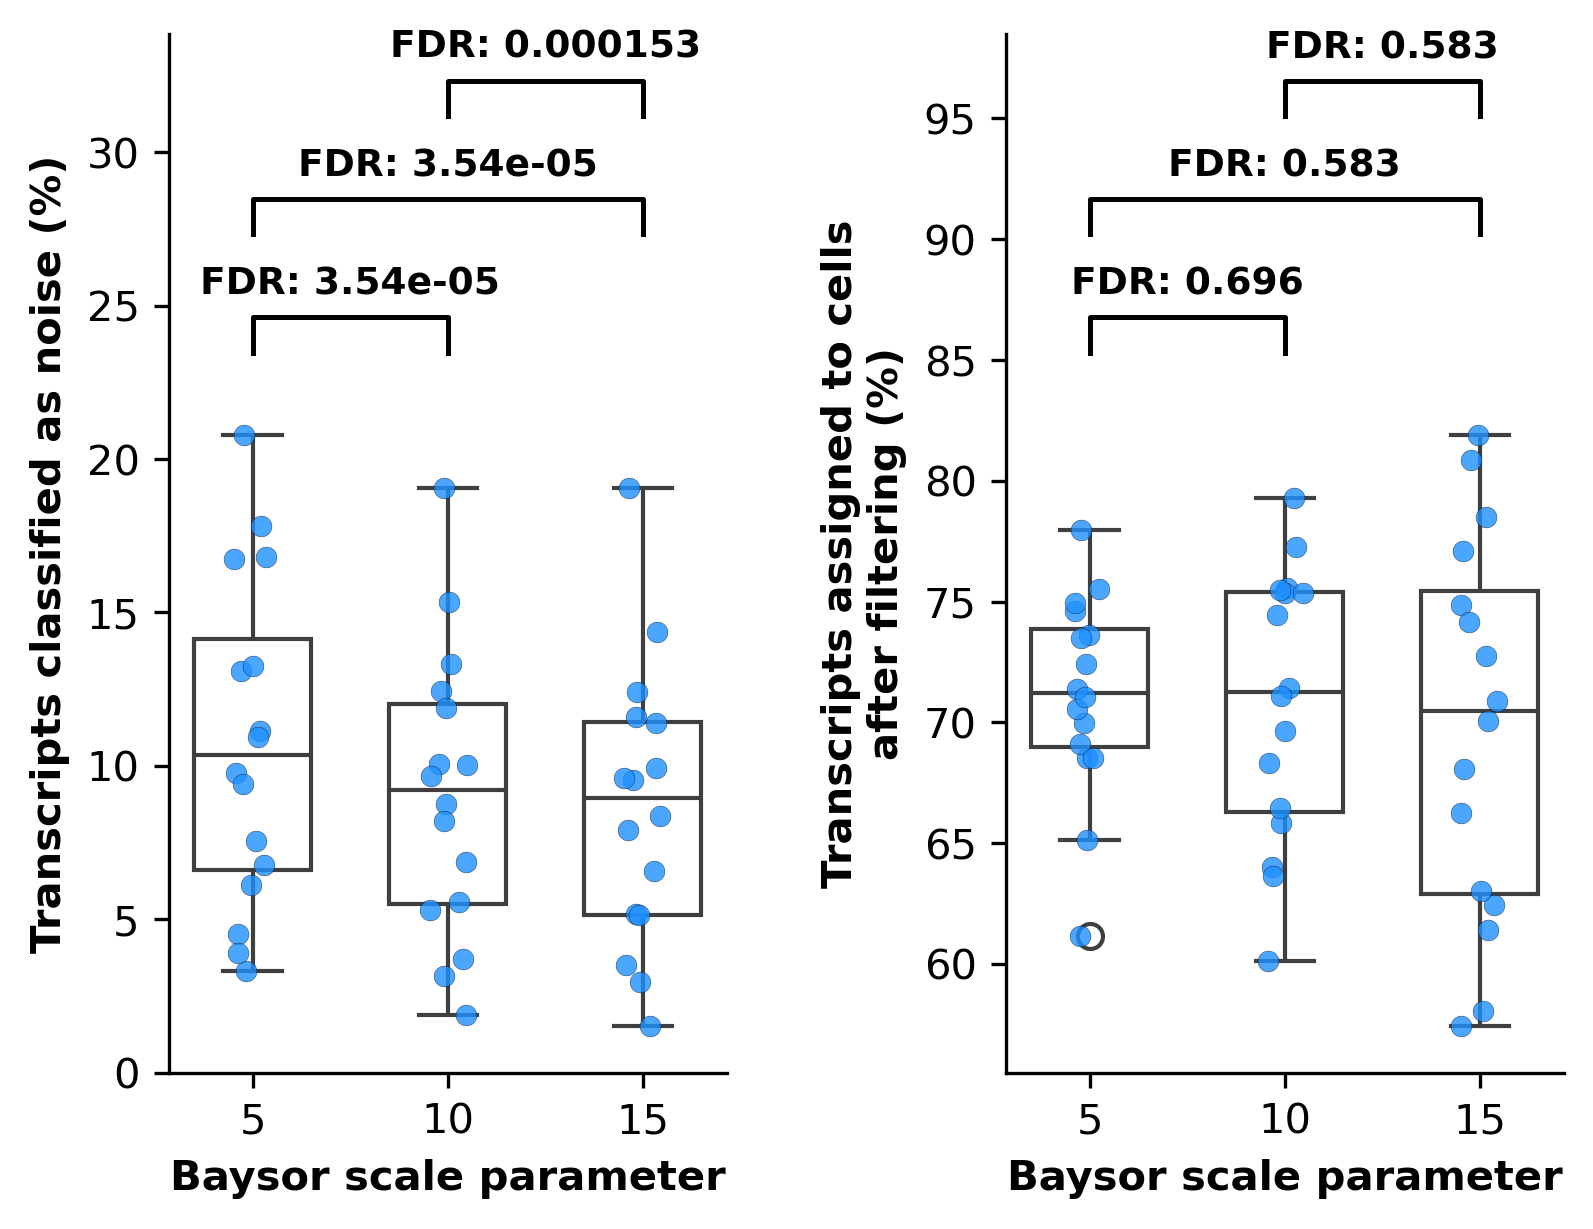

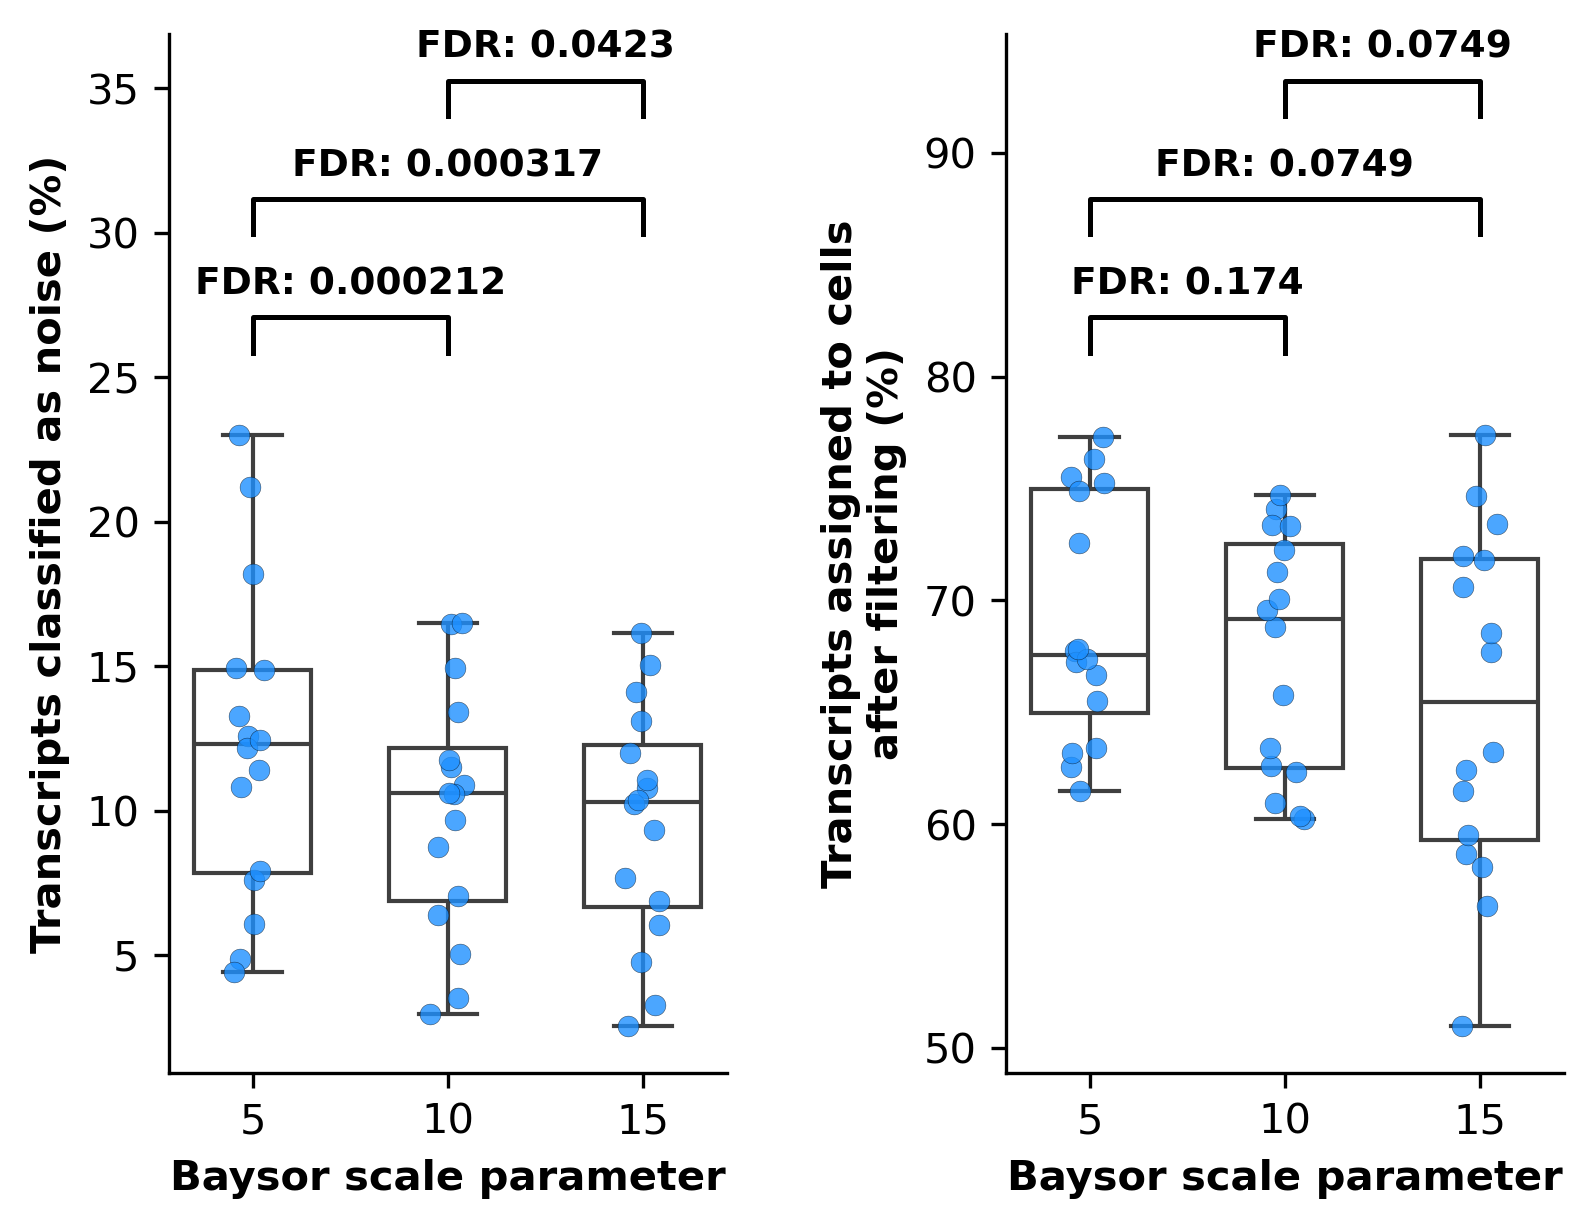

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import ConnectionPatch


## Load dataframes with noise and HQ transcript percentages
proc_dir="../../xenium_data/processed_data"
noise_pct_df=pd.read_csv(f"{proc_dir}/noise_pct_df.csv.gz",index_col=0)
hq_transcript_df=pd.read_csv(f"{proc_dir}/hq_transcript_df.csv.gz",index_col=0)


## SELECT THE BEST SEGMENTATION FOR EACH SCALE_PARAM FOR EACH MODEL FIRST
# ==> this way only the best segmentations per scale are getting compared
noise_pct_df_=pd.DataFrame(data=np.nan,index=noise_pct_df.index,columns=noise_pct_df.columns)
hq_transcript_df_=pd.DataFrame(data=np.nan,index=hq_transcript_df.index,columns=hq_transcript_df.columns)
scale_order=['5', '10', '15']

best_model_dict = return_best_model_dict()

for scale_param in scale_order:

    best_model_df = best_model_dict['high_confidence_auc'][scale_param]
    avg_assignment_conf_thr=0.75
    best_model_df[avg_assignment_conf_thr]
    
    for samp in best_model_df.index:
        #print(best_model_df.loc[samp,avg_assignment_conf_thr])
        seg_meth=best_model_df.loc[samp,avg_assignment_conf_thr]
        seg_meth='assignments_'+seg_meth
    
        #noise_pct_df_[samp]=np.nan
        noise_pct_df_.loc[seg_meth,samp]=noise_pct_df.loc[seg_meth,samp]
    
        #hq_transcript_df_[samp]=np.nan
        hq_transcript_df_.loc[seg_meth,samp]=hq_transcript_df.loc[seg_meth,samp]
    
        hq_transcript_df_
        #print(seg_meth,samp,noise_pct_df.loc[seg_meth,samp])



#df_list = [noise_pct_df, hq_transcript_df][:2]  # Select DataFrames
df_list = [noise_pct_df_, hq_transcript_df_][:2]  # Select DataFrames
title_list = ['Transcripts classified as noise (%)', 'Transcripts assigned to cells\nafter filtering (%)'][:2]
scale_order = ['5', '10', '15']  # Ensure consistent order
comparisons = list(itertools.combinations(scale_order,2)) # Paired t-test comparisons

for panel in ['Panel1', 'Panel2'][:]:
    ncols = 2
    nrows = int(np.ceil(len(df_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 4.5))
    #fig.suptitle(f'{panel} - Comparison of Baysor segmentations across scale parameters', fontsize=14, fontweight='bold',y=1)

    for n, (plot_title, df) in enumerate(zip(title_list, df_list)):
        ax = axes.flatten()[n]

        df['scale_param']=(df.reset_index()['index'].str.split('scale_',expand=True)[1].str.split('_',expand=True)[0]).values
        df['Nucleus presegmentation']=(df.reset_index()['index'].str.split('scale_',expand=True)[0].str.split('assignments_',expand=True)[1].str.split('-',expand=True)[1]).values

        df = df.loc[:, df.columns[df.columns.str.startswith(panel)].tolist() + ['scale_param', 'Nucleus presegmentation'][:]]
        df['Nucleus presegmentation'] = df['Nucleus presegmentation'].str.strip('_')

        df = df.replace({'CPn': "Cellpose-nucleus",
                         'CPc': "Cellpose-cytoplasm",
                         '10x': "10x-native",
                         'no_segmentation': "No presegmentation"})
        
        ## For Patient 6 not all segmentations with different scales could be performed due to computational instability 
        ## ==> drop these samples from the t-test, as they don't have an equal value among each scale parameter
        #df=df.dropna(how='any',axis=1)

        plot_df = df.melt(id_vars=['scale_param', 'Nucleus presegmentation'][:])
        plot_df=plot_df.loc[~plot_df['value'].isna(),:]

        # Perform boxplot
        sns.boxplot(data=plot_df, y='value', x='scale_param', order=scale_order,
                    boxprops={'facecolor': 'none'}, ax=ax, width=0.6)

        # Add scatter points (stripplot)
        sns.stripplot(data=plot_df, y='value', x='scale_param', order=scale_order, ax=ax,
                      color="dodgerblue", alpha=0.8, edgecolor='black', linewidth=0.1)

        #ax.set_ylim(ax.get_ylim()[0]*0.9,ax.get_ylim()[1]*1.3)
        ax.spines[['top','right']].set_visible(False)
        
        plt.subplots_adjust(wspace=0.5)


        ### Save source data for plot               
        source_df = plot_df[['scale_param','value']]
        source_df.columns=['Baysor scale parameter',plot_title]
                
        source_dir=os.path.join(proc_dir,'source_data','first_revision')
        os.makedirs(source_dir,exist_ok=True)
        
        
        if panel=='Panel1' and plot_title=='Transcripts classified as noise (%)':                           
            fn=os.path.join(source_dir,'Suppl_Fig35A.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and plot_title=='Transcripts assigned to cells\nafter filtering (%)':                             
            fn=os.path.join(source_dir,'Suppl_Fig35B.xlsx')
            source_df.to_excel(fn)

        if panel=='Panel2' and plot_title=='Transcripts classified as noise (%)':                           
            fn=os.path.join(source_dir,'Suppl_Fig36A.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and plot_title=='Transcripts assigned to cells\nafter filtering (%)':                             
            fn=os.path.join(source_dir,'Suppl_Fig36B.xlsx')
            source_df.to_excel(fn)

        

        # Perform **paired t-tests** between scale parameters
        p_values = []
        for scale1, scale2 in comparisons:
            subset1 = plot_df[plot_df["scale_param"] == scale1]["value"].dropna()
            subset2 = plot_df[plot_df["scale_param"] == scale2]["value"].dropna()

            if len(subset1) == len(subset2):  # Ensure paired samples
                t_stat, p_val = stats.ttest_rel(subset1, subset2)
            else:
                p_val = np.nan  # Skip if pairing is not possible
            
            p_values.append(p_val)

        # Apply **FDR correction**
        _, fdr_pvals, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

        # **Annotate boxplots with FDR-corrected p-values**
        y_max = plot_df["value"].max() * 1
        bracket_spacing = (y_max - plot_df["value"].min()) * 0.2  # Adjust spacing for stacked brackets
        text_spacing = bracket_spacing * 0.13 # More space for text

        for i, ((scale1, scale2), fdr_p) in enumerate(zip(comparisons, fdr_pvals[:3])):
            x1, x2 = scale_order.index(scale1), scale_order.index(scale2)
            y_pos = y_max + (i+1) * bracket_spacing  # Stack brackets
            y_max_=y_pos - bracket_spacing*0.3

            # Draw bracket at different heights
            ax.plot([x1, x1, x2, x2], [y_max_, y_pos, y_pos, y_max_], lw=1.2, c='black')

            # Annotate FDR-adjusted p-value
            ax.text((x1 + x2) / 2, y_pos + text_spacing, f"FDR: {fdr_p:.3g}", ha='center', va='bottom', fontsize=9, fontweight='bold')

        # Set labels and title
        ax.set_ylabel(plot_title, fontweight='bold', fontsize=10)
        ax.set_xlabel('Baysor scale parameter', fontweight='bold', fontsize=10)

    #plt.tight_layout()
    #plt.show()

    ## SAvefig    
    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    os.makedirs(os.path.join(proc_dir,'figure_plots','SFigA','segment_QC_across_scale_param'),exist_ok=True)
    fn=os.path.join(proc_dir,'figure_plots','SFigA','segment_QC_across_scale_param',f'{panel}_transcript_QC_boxplots_across_scale_params.png')
    fig.savefig(fn, dpi=300, bbox_inches='tight')


## QC all segmentations - across conditions

### Suppl.FIG.A - Boxplots with unpaired t-test results

high_confidence_auc


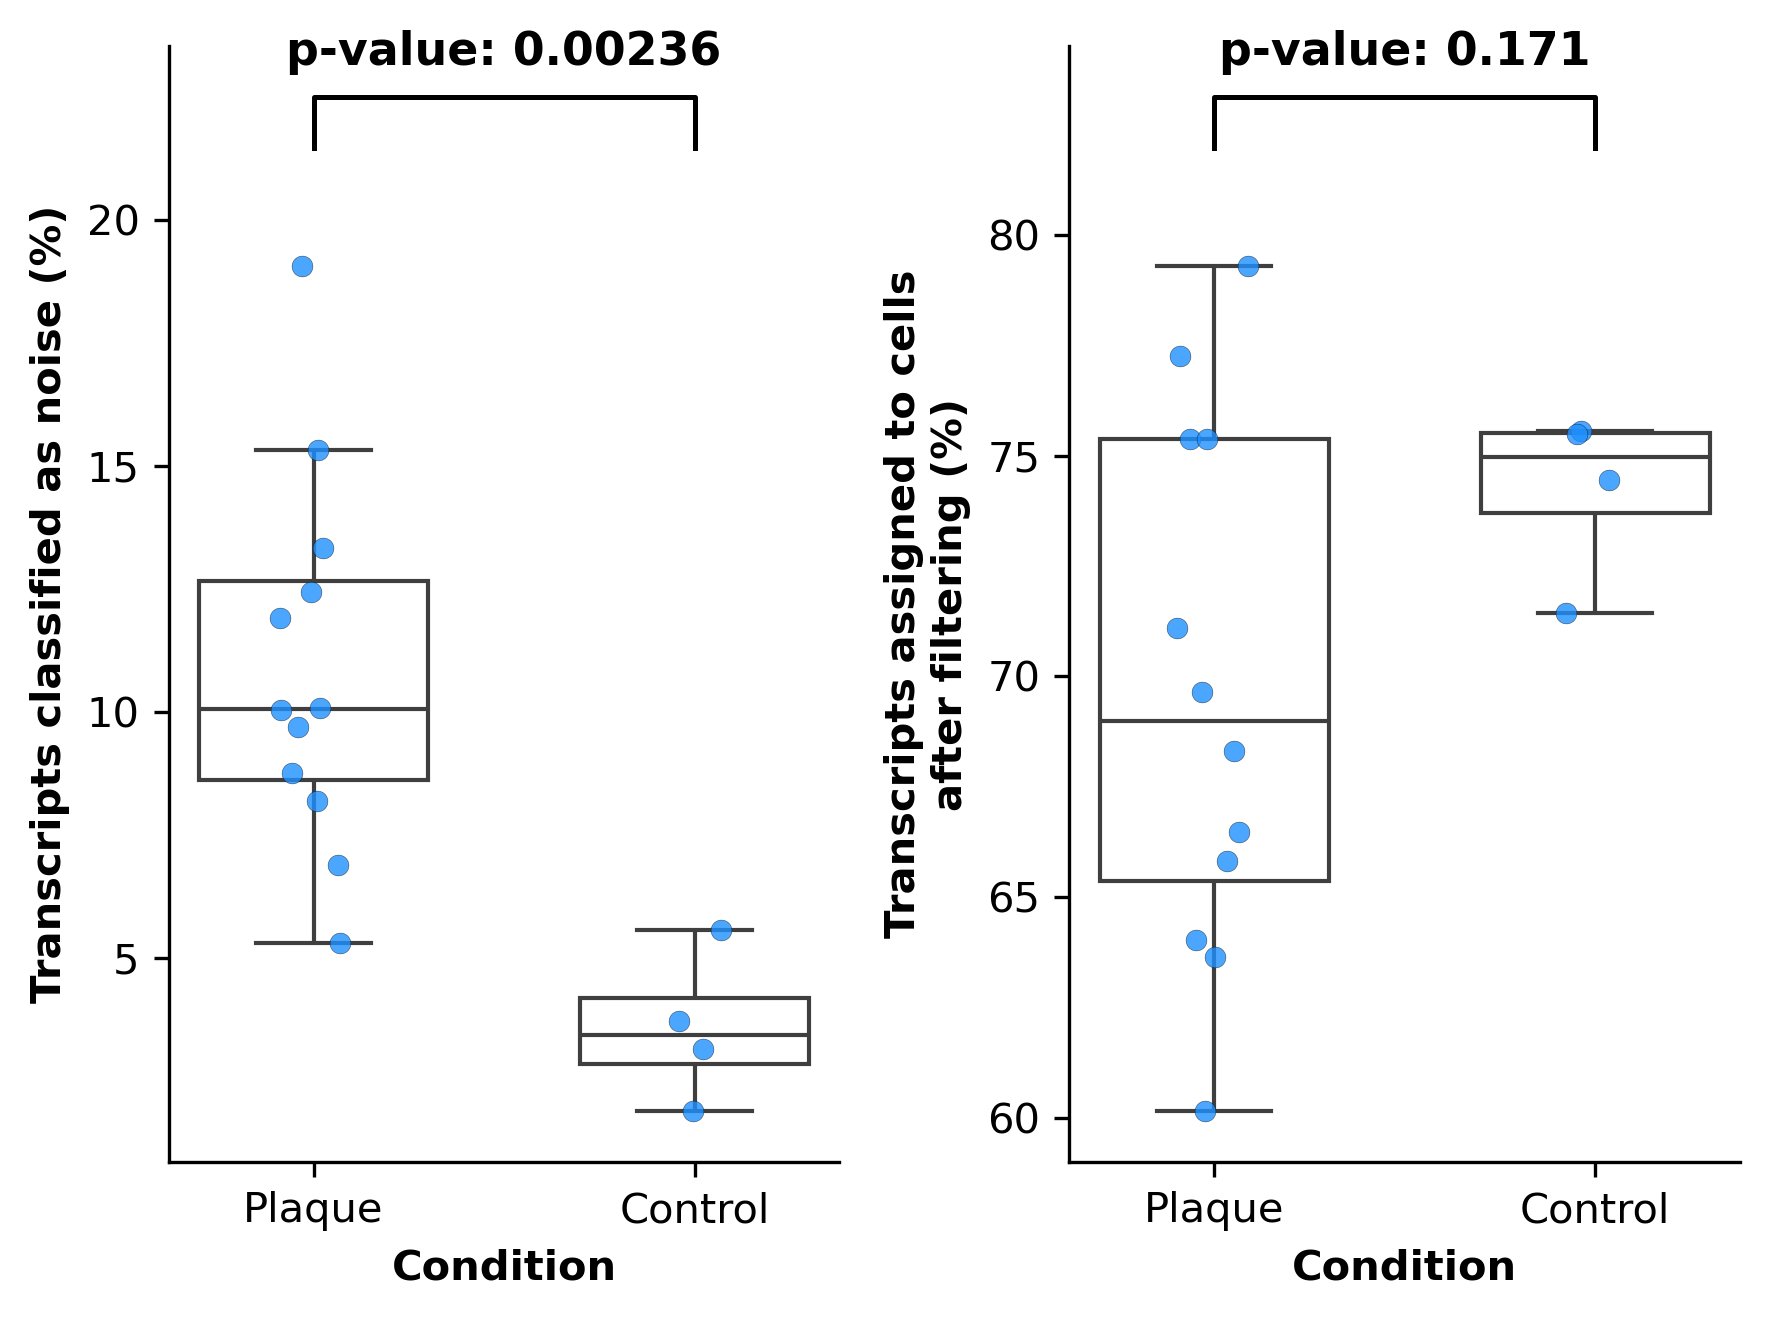

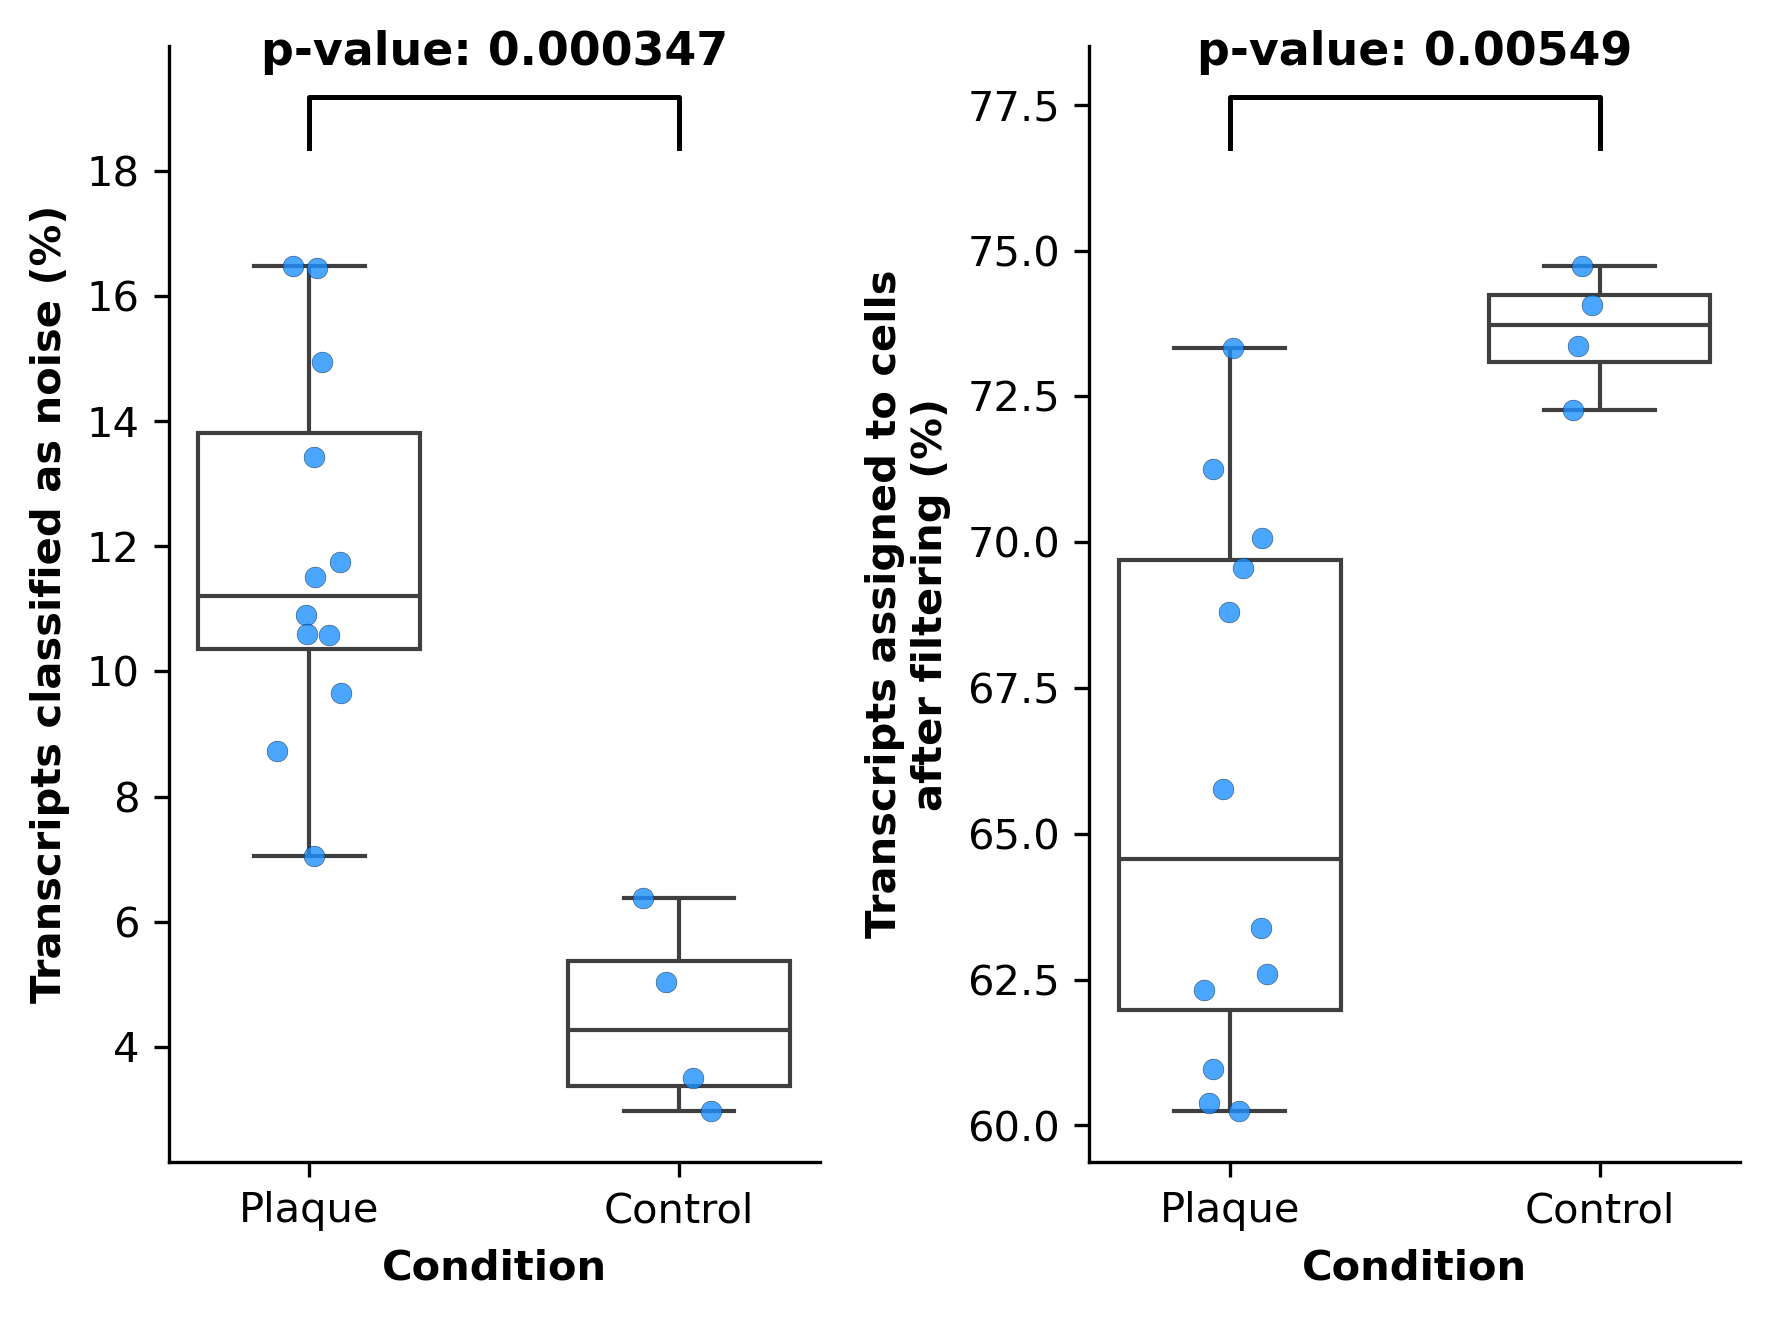

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import ConnectionPatch


## Load dataframes with noise and HQ transcript percentages
proc_dir="../../xenium_data/processed_data"
noise_pct_df=pd.read_csv(f"{proc_dir}/noise_pct_df.csv.gz",index_col=0)
hq_transcript_df=pd.read_csv(f"{proc_dir}/hq_transcript_df.csv.gz",index_col=0)


## SELECT THE BEST SEGMENTATION FOR THE FINAL DATA USED FOR ANALYSIS (SCALE=10) FOR EACH MODEL
# ==> this way only the best segmentations per scale are getting compared
noise_pct_df_=pd.DataFrame(data=np.nan,index=noise_pct_df.index,columns=noise_pct_df.columns)
hq_transcript_df_=pd.DataFrame(data=np.nan,index=hq_transcript_df.index,columns=hq_transcript_df.columns)
scale_order=['5', '10', '15']

best_model_dict = return_best_model_dict()

for scale_param in scale_order[1:2]:

    best_model_df = best_model_dict['high_confidence_auc'][scale_param]
    avg_assignment_conf_thr=0.75
    best_model_df[avg_assignment_conf_thr]
    
    for samp in best_model_df.index:
        #print(best_model_df.loc[samp,avg_assignment_conf_thr])
        seg_meth=best_model_df.loc[samp,avg_assignment_conf_thr]
        seg_meth='assignments_'+seg_meth
    
        #noise_pct_df_[samp]=np.nan
        noise_pct_df_.loc[seg_meth,samp]=noise_pct_df.loc[seg_meth,samp]
    
        #hq_transcript_df_[samp]=np.nan
        hq_transcript_df_.loc[seg_meth,samp]=hq_transcript_df.loc[seg_meth,samp]
    
        hq_transcript_df_
        #print(seg_meth,samp,noise_pct_df.loc[seg_meth,samp])



df_list = [noise_pct_df, hq_transcript_df][:2]  # Select DataFrames
df_list = [noise_pct_df_, hq_transcript_df_][:2]  # Select DataFrames
title_list = ['Transcripts classified as noise (%)', 'Transcripts assigned to cells\nafter filtering (%)'][:2]
#scale_order = ['5', '10', '15'] 
scale_order = ['Control','Plaque'] # Ensure consistent order
comparisons = list(itertools.combinations(scale_order,2)) # Paired t-test comparisons

for panel in ['Panel1', 'Panel2'][:]:
    ncols = 2
    nrows = int(np.ceil(len(df_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 4.5))
    #fig.suptitle(f'{panel} - Comparison of Baysor segmentations across scale parameters', fontsize=14, fontweight='bold',y=1)

    for n, (plot_title, df) in enumerate(zip(title_list, df_list)):
        ax = axes.flatten()[n]

        df['scale_param']=(df.reset_index()['index'].str.split('scale_',expand=True)[1].str.split('_',expand=True)[0]).values
        df['Nucleus presegmentation']=(df.reset_index()['index'].str.split('scale_',expand=True)[0].str.split('assignments_',expand=True)[1].str.split('-',expand=True)[1]).values

        df = df.loc[:, df.columns[df.columns.str.startswith(panel)].tolist() + ['scale_param', 'Nucleus presegmentation'][:]]
        df['Nucleus presegmentation'] = df['Nucleus presegmentation'].str.strip('_')

        df = df.replace({'CPn': "Cellpose-nucleus",
                         'CPc': "Cellpose-cytoplasm",
                         '10x': "10x-native",
                         'no_segmentation': "No presegmentation"})
        
        ## For Patient 6 not all segmentations with different scales could be performed due to computational instability 
        ## ==> drop these samples from the t-test, as they don't have an equal value among each scale parameter
        #df=df.dropna(how='any',axis=1)

        plot_df = df.melt(id_vars=['scale_param', 'Nucleus presegmentation'][:])
        plot_df=plot_df.loc[~plot_df['value'].isna(),:]
        plot_df['Condition'] = plot_df['variable'].str.split('_',expand=True)[2].replace({'D':'Plaque','H':'Control'}).values

        # Perform boxplot
        sns.boxplot(data=plot_df, y='value', 
                    x='Condition',
                    #hue='scale_param', 
                    #order=scale_order,
                    showfliers=False,
                    boxprops={'facecolor': 'none'}, ax=ax, width=0.6)

        # Add scatter points (stripplot)
        sns.stripplot(data=plot_df, y='value', 
                      #hue='scale_param', 
                      #order=scale_order, 
                      ax=ax,
                      x='Condition',dodge=True,
                      color="dodgerblue", alpha=0.8, 
                      edgecolor='black', linewidth=0.1)

        #ax.set_ylim(ax.get_ylim()[0]*0.9,ax.get_ylim()[1]*1.3)
        ax.spines[['top','right']].set_visible(False)

        plt.subplots_adjust(wspace=0.5)



        ### Save source data for plot               
        source_df = plot_df[['Condition','value']]
        source_df.columns=['Condition',plot_title]
                
        source_dir=os.path.join(proc_dir,'source_data','first_revision')
        os.makedirs(source_dir,exist_ok=True)
        
        if panel=='Panel1' and plot_title=='Transcripts classified as noise (%)':                           
            fn=os.path.join(source_dir,'Suppl_Fig35C.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and plot_title=='Transcripts assigned to cells\nafter filtering (%)':                             
            fn=os.path.join(source_dir,'Suppl_Fig35D.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and plot_title=='Transcripts classified as noise (%)':                           
            fn=os.path.join(source_dir,'Suppl_Fig36C.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and plot_title=='Transcripts assigned to cells\nafter filtering (%)':                             
            fn=os.path.join(source_dir,'Suppl_Fig36D.xlsx')
            source_df.to_excel(fn)

        
        
        # Perform **paired t-tests** between scale parameters
        p_values = []
        for scale1, scale2 in comparisons:
            subset1 = plot_df[plot_df["Condition"] == scale1]["value"].dropna()
            subset2 = plot_df[plot_df["Condition"] == scale2]["value"].dropna()

            #if len(subset1) == len(subset2):  # Ensure paired samples
            t_stat, p_val = stats.ttest_ind(subset1, subset2)
            #else:
            #p_val = np.nan  # Skip if pairing is not possible
            
            p_values.append(p_val)

        # Apply **FDR correction**
        _, fdr_pvals, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

        # **Annotate boxplots with FDR-corrected p-values**
        y_max = plot_df["value"].max() * 1
        bracket_spacing = (y_max - plot_df["value"].min()) * 0.2  # Adjust spacing for stacked brackets
        text_spacing = bracket_spacing * 0.13 # More space for text

        for i, ((scale1, scale2), fdr_p) in enumerate(zip(comparisons, fdr_pvals[:])):
            x1, x2 = scale_order.index(scale1), scale_order.index(scale2)
            y_pos = y_max + (i+1) * bracket_spacing  # Stack brackets
            y_max_=y_pos - bracket_spacing*0.3

            # Draw bracket at different heights
            ax.plot([x1, x1, x2, x2], [y_max_, y_pos, y_pos, y_max_], lw=1.2, c='black')

            # Annotate FDR-adjusted p-value
            ax.text((x1 + x2) / 2, y_pos + text_spacing, f"p-value: {fdr_p:.3g}", ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Set labels and title
        ax.set_ylabel(plot_title, fontweight='bold', fontsize=10)
        ax.set_xlabel('Condition', fontweight='bold', fontsize=10)

    plt.tight_layout()
    #plt.show()

    ## SAvefig    
    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    os.makedirs(os.path.join(proc_dir,'figure_plots','SFigA','segment_QC_across_conditions'),exist_ok=True)
    fn=os.path.join(proc_dir,'figure_plots','SFigA','segment_QC_across_conditions',f'{panel}_transcript_QC_boxplots_across_conditions.png')
    fig.savefig(fn, dpi=300, bbox_inches='tight')


## QC - save final segmentations for SFig. C later

In [4]:
best_model_dict = return_best_model_dict()
data_dir="../../xenium_data/"#processed_data/cell_segmentation"

seg_transcr_dict,noise_pct_dict,hq_transcript_dict={},{},{}

for panel in ['Panel1','Panel2'][:]:
    #noise_dict[panel]={}

    for scale_param in ['5','10','15','5|10|15'][1:2]:
        #noise_dict[panel][scale_param]={}

        adata=adata_dict_[scale_param][panel]
                
        #large_cell_samples = adata_dict_[scale_param][panel][largest_cell_idx,:].obs[['cell_mask_area_um2','original_sample']]
        orig_samples=np.sort(adata_dict_[scale_param][panel].obs['original_sample'].unique().tolist())
        '''
        ncols=4
        nrows=int(np.ceil(len(largest_cell_idx)/ncols))
        fig=plt.figure(figsize=(ncols*6,nrows*6))
        fig.suptitle(f'{panel} - scale_param:{scale_param} - {celltype}',fontsize=14,fontweight='bold',y=1.02)
        n=0
        '''
        #for orig_sample in ['Panel1_P9_Pl']: #orig_samples[5:6]:


        for orig_sample in (orig_samples[:]):
            print(orig_sample)
        
            adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
            
            proc_dir="../../xenium_data/processed_data/baysor_processed_output"
            ## Replace 
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                if old in orig_sample:
                    orig_sample_ = orig_sample.replace(old, new)

                    if panel=='Panel2':
                        orig_sample__=orig_sample_.replace('Panel2','Panel1')
                    else:
                      orig_sample__=orig_sample_  
                
            filename=f'{proc_dir}/{orig_sample__}_reg_area_dict.pickle'
            with open(filename, 'rb') as handle:
                reg_area_dict=pickle.load(handle)
                #print('sampl_name',orig_sample)
        
            #large_cell_samples_=[orig_sample]
            
            #img_array = load_slide_img(large_cell_samples_)

            auc_metric='high_confidence_auc'
            avg_assignment_conf_thr=0.75 #0.75


            ## Extract name of best baysor model to use for the sample
            best_model=best_model_dict[auc_metric][scale_param].loc[orig_sample_,avg_assignment_conf_thr]
            #print(best_model)
            bays_model_name='assignments_'+best_model
        
            baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',orig_sample_)
            #print(panel_sample_name)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,index_col=0)
                
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue

            ## LOAD NOISE DICT ==> contains transcript IDS which are localised on sample area 
            proc_dir="../../xenium_data/processed_data/baysor_processed_output"
            filename=f'{proc_dir}/{orig_sample_}_noise_dict.pickle'
            with open(filename, 'rb') as handle:
                noise_dict = pickle.load(handle)  

            
            ## Indicate which transcript is located within the sample area 
            seg['sample_region']=np.nan
            seg['on_sample_area']='no'
            
            for region in [*noise_dict][:-1]:
                idx=noise_dict[region]['transcr_within_sample_area']
                seg.loc[seg['transcript_id'].isin(idx),'sample_region']=region
                reg_area_dict[region]['area']

            idx=noise_dict['whole_slide']['transcr_within_sample_area']
            seg.loc[seg['transcript_id'].isin(idx),'on_sample_area']='yes'

            ## CALCULATE THE PERCENTAGE OF TRANSCRIPTS CLASSIFIED AS NOISE USING TRANSCRIPTS ONLY THAT ARE LOCATED ON THE SAMPLE!
            qv_thr=20
            seg_noise=seg[(seg['qv']>qv_thr)\
                        &(seg['cell'].isna())\
                        &(seg['on_sample_area']=='yes')
                        ]

            seg_not_noise=seg[(seg['qv']>qv_thr)\
                            &(~seg['cell'].isna())\
                             &(seg['on_sample_area']=='yes')
                                ]

            noise_pct_in_sample_area=100 * (seg_noise.shape[0] / (seg_not_noise.shape[0] + seg_noise.shape[0]))
            noise_pct_dict[orig_sample]=noise_pct_in_sample_area


            ## CALCULATE PERCENTAGE OF FINAL TRANSCRIPTS BY DIVIDING THE NUMBER OF HQ TRANSCRIPTS ON THE SAMPLE AREA 
            #. WITH ALL TRANSCRIPTS LOCATED ON THE SAMPLE AREA
            confidence_thr=0.5
            assignment_confidence_thr=0.7
            
            final_transcr=seg[(~seg['cell'].isna())&\
                                (seg['confidence']>confidence_thr)&\
                                (seg['assignment_confidence']>assignment_confidence_thr)&\
                                (seg['qv']>qv_thr)\
                                &(seg['on_sample_area']=='yes')]

            hq_pct_in_sample_area=100 * (final_transcr.shape[0] / (seg_not_noise.shape[0] + seg_noise.shape[0]))
            #print(bays_model_name,hq_pct_in_sample_area)
            
            hq_transcript_dict[orig_sample]=hq_pct_in_sample_area


            ## ADD ALL NUMBER OF TRANSCRIPTS ON SAMPLE AREA
            seg_transcr_dict[orig_sample]=seg[(seg['qv']>qv_thr)\
                                              #&(~seg['cell'].isna())\
                                              &(seg['on_sample_area']=='yes')
                                                            ].shape[0]

    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    fn=os.path.join(proc_dir,f'{panel}_filtered_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_noise_pct_dict.pkl')
    with open(fn, 'wb') as handle:
        pickle.dump(noise_pct_dict,handle)
    
    fn=os.path.join(proc_dir,f'{panel}_filtered_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_hq_transcript_dict.pkl')
    with open(fn, 'wb') as handle:
        pickle.dump(hq_transcript_dict,handle)
    
    fn=os.path.join(proc_dir,f'{panel}_filtered_cells_scale_{scale_param}_asg_conf_{avg_assignment_conf_thr}_seg_transcr_dict.pkl')
    with open(fn, 'wb') as handle:
        pickle.dump(seg_transcr_dict,handle)
        
            

high_confidence_auc
Panel1_P10_Pl
Panel1_P11_Pl
Panel1_P12_Pl
Panel1_P1_Ctrl
Panel1_P1_Pl
Panel1_P2_Ctrl
Panel1_P2_Pl
Panel1_P3_Ctrl
Panel1_P3_Pl
Panel1_P4_Ctrl
Panel1_P4_Pl
Panel1_P5_Pl
Panel1_P6_Pl
Panel1_P7_Pl
Panel1_P8_Pl
Panel1_P9_Pl
Panel2_P10_Pl
Panel2_P11_Pl
Panel2_P12_Pl
Panel2_P1_Ctrl
Panel2_P1_Pl
Panel2_P2_Ctrl
Panel2_P2_Pl
Panel2_P3_Ctrl
Panel2_P3_Pl
Panel2_P4_Ctrl
Panel2_P4_Pl
Panel2_P5_Pl
Panel2_P6_Pl
Panel2_P7_Pl
Panel2_P8_Pl
Panel2_P9_Pl


/tmp/ipykernel_139433/555066587.py:65: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  seg=pd.read_csv(seg_fn,index_col=0)


# CELL NUMBERS ACROSS SCALE_PARAM MODELS

## Suppl.FIG.A

In [9]:
plot_df





,count,proportion,Scale parameter
final_low_level_celltype,,,
VSMC_fb-like,23734,0.166591,5
VSMC_contr,23276,0.163376,5
Mac_TREM2hi,22229,0.156027,5
VSMC_inflamed,21916,0.153830,5
Mac_C1Q/Mac_S100A8hi,12702,0.089156,5
Inflammatory_mixed_cell,12200,0.085633,5
CD8_Teff-cell,8491,0.059599,5
Mac_ITGAXhi,7128,0.050032,5
EC_1,5290,0.037131,5


In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


for panel in ['Panel1','Panel2'][:]:

    for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][1:]:
        l=[]
        for scale_param in ['5','10','15','5|10|15'][:-1]:
            adata_subs=adata_dict_[scale_param][panel]
            adata_subs.obs['Scale parameter']=scale_param
    
            abs_counts=adata_subs.obs[cellt_coln].value_counts()
            norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
            count_df=pd.concat([abs_counts,norm_counts],axis=1)
            count_df['Scale parameter']=scale_param
            l.append(count_df)
        
        
        plot_df=pd.concat(l,axis=0)


        ### Save source data for plot               
        source_df=plot_df.reset_index()[['final_low_level_celltype','count','Scale parameter']]
        source_df.columns=['final_low_level_celltype','Cell count','Scale parameter']
        
        source_dir=os.path.join(proc_dir,'source_data','first_revision')
        os.makedirs(source_dir,exist_ok=True)
        
        
        if panel=='Panel1':                           
            fn=os.path.join(source_dir,'Suppl_Fig35E.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2':                           
            fn=os.path.join(source_dir,'Suppl_Fig36E.xlsx')
            source_df.to_excel(fn)

        
        
        met_colnames=['count','proportion'][:1]
        met_coln_titles=['Cell count','Cell fraction'][:1]
        
        for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):

            fig,ax=plt.subplots(1,1,figsize=(9,2.9))
            #fig.suptitle(panel)
    
            sns.barplot(data=plot_df.reset_index(),x=cellt_coln,y=met_coln,hue='Scale parameter')
            #sns.boxplot(data=plot_df,y='cell_mask_area_um2',x='final_low_level_celltype',hue='scale_param',ax=ax,boxprops={'facecolor': 'none'})
    
            #ax.set_ylim(None,np.quantile(plot_df[met_coln],1))
            
            # Rotate x-axis tick labels by 45 degrees
            x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
            x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
            ax.set_xticklabels(x_ticks)
            plt.xticks(rotation=90,fontsize=7.5)

            ax.set_ylabel(met_coln_title,fontsize=12,fontweight='bold')
            ax.set_xlabel(None)
            ax.spines[['top','right']].set_visible(False)
       
  
            ## SAvefig    
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            os.makedirs(os.path.join(proc_dir,'figure_plots','SFigA','cell_counts_across_scale_param'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','SFigA','cell_counts_across_scale_param',f'{panel}_{cellt_coln}_{met_coln}_across_scale_params.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')

            


# PLOT CELL SIZE DISTRIUBTIONS WITHIN CELLTYPES ACROSS SCALE_PARAMS MODELS

## Suppl.FIG.A

In [31]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

expr_dict={}

for panel in ['Panel1','Panel2'][:]:
    expr_dict[panel]={}

    l=[]
    for scale_param in ['5','10','15','5|10|15'][:-1]:
        adata_subs=adata_dict_[scale_param][panel]
        adata_subs.obs['Scale parameter']=scale_param
        l.append(adata_subs.obs)
    
    
    plot_df=pd.concat(l,axis=0)

    for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][1:]:
        
        met_colnames=['cell_mask_area_um2','n_counts','n_genes',
                      'elongation','avg_assign_conf_hq_transcripts',][:-2]
        met_coln_titles=['Cell mask area (µm$^2$)', 'Log10 transcript count/cell','Number of genes/cell',
                         'Elongation','Avg. assignment confidence \nper cell after filtering'][:-2]
                        
        
        for met_coln_title,met_coln in zip(met_coln_titles,met_colnames[:]):
            print(met_coln,met_coln_title)
            
            fig,ax=plt.subplots(1,1,figsize=(9,2.9))
            #fig.suptitle(panel)
        
            sns.boxplot(data=plot_df,y=met_coln,x=cellt_coln,hue='Scale parameter',ax=ax,boxprops={'facecolor': 'none'},showfliers=False)
            #sns.violinplot(data=plot_df, y=met_coln, x=cellt_coln, hue='Scale parameter', ax=ax, split=True, linewidth=1, inner=None, palette='muted')
            sns.stripplot(data=plot_df,y=met_coln,x=cellt_coln,hue='Scale parameter',dodge=True,ax=ax,s=0.5,legend=False)
            
            if met_coln=='n_counts':
                ax.set_yscale('log')
                #ax.set_ylim(0,np.quantile(plot_df[met_coln],0.999))

            ax.set_ylabel(met_coln_title,fontsize=9,fontweight='bold')
            ax.set_xlabel(None)
            ax.spines[['top','right']].set_visible(False)
            
            # Rotate x-axis tick labels by 45 degrees
            x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
            x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
            ax.set_xticklabels(x_ticks)
            plt.xticks(rotation=90,fontsize=7.5)
    

            ## SAvefig    
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            os.makedirs(os.path.join(proc_dir,'figure_plots','SFigA','cell_feature_distr_across_scale_param'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','SFigA','cell_feature_distr_across_scale_param',f'{panel}_{cellt_coln}_{met_coln}_distr_across_scale_params.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')
            plt.close()

            
            ### Save source data for plot               
            source_df = plot_df[[met_coln,'final_low_level_celltype','Scale parameter']]
            source_df.columns=[met_coln_title.replace('$',''),'final_low_level_celltype','Scale parameter']
            source_df.index.name='Cell_ID'
            
            source_dir=os.path.join(proc_dir,'source_data','first_revision')
            os.makedirs(source_dir,exist_ok=True)
            
            
            if cellt_coln=='final_low_level_celltype' and panel=='Panel1' and met_coln=='cell_mask_area_um2':                           
                fn=os.path.join(source_dir,'Suppl_Fig35F.xlsx')
                source_df.to_excel(fn)
            
            if cellt_coln=='final_low_level_celltype' and panel=='Panel2' and met_coln=='cell_mask_area_um2':                            
                fn=os.path.join(source_dir,'Suppl_Fig36F.xlsx')
                source_df.to_excel(fn)

            if cellt_coln=='final_low_level_celltype' and panel=='Panel1' and met_coln=='n_counts':                           
                fn=os.path.join(source_dir,'Suppl_Fig33D.xlsx')
                source_df.to_excel(fn)
            
            if cellt_coln=='final_low_level_celltype' and panel=='Panel2' and met_coln=='n_counts':                            
                fn=os.path.join(source_dir,'Suppl_Fig34D.xlsx')
                source_df.to_excel(fn)

            if cellt_coln=='final_low_level_celltype' and panel=='Panel1' and met_coln=='n_genes':                           
                fn=os.path.join(source_dir,'Suppl_Fig33E.xlsx')
                source_df.to_excel(fn)
            
            if cellt_coln=='final_low_level_celltype' and panel=='Panel2' and met_coln=='n_genes':                            
                fn=os.path.join(source_dir,'Suppl_Fig34E.xlsx')
                source_df.to_excel(fn)
            



cell_mask_area_um2 Cell mask area (µm$^2$)


/tmp/ipykernel_292664/3989289417.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


n_counts Log10 transcript count/cell


/tmp/ipykernel_292664/3989289417.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


n_genes Number of genes/cell


...

/tmp/ipykernel_292664/3989289417.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


n_counts Log10 transcript count/cell


/tmp/ipykernel_292664/3989289417.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


n_genes Number of genes/cell


/tmp/ipykernel_292664/3989289417.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


# GENE COUNTS PER CELL - ACROSS PARAMETERS

## Suppl.FIG. A

In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

expr_dict={}

for panel in ['Panel1','Panel2'][:]:

    scale_params=['5','10','15','5|10|15'][:-1]

    colors = plt.cm.get_cmap('tab10', 10) 
    scale_param_color_mapping = {scale: colors(i) for i, scale in enumerate(scale_params)}
 

    nrows=1
    ncols=len(scale_params)
    
    #fig=plt.figure(figsize=(ncols*4,nrows*3))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*2.9),
                         sharey=False,sharex=False)



    l=[]
    for ax,scale_param in zip(axes,scale_params):
        adata_subs=adata_dict_[scale_param][panel]
        adata_subs.obs['Scale parameter']=scale_param
        #l.append(adata_subs.obs)

        #ax=fig.add_subplot(nrows,ncols,n+1)
        adata_subs.obs['log_n_counts']=np.log10(adata_subs.obs['n_counts'])
 
        sns.scatterplot(data=adata_subs.obs,x='log_n_counts',y='n_genes',ax=ax,s=3,
                        color=scale_param_color_mapping[scale_param],
                        alpha=0.8,
                        #hue='original_sample',
                       )

        ax.set_ylabel('Num. of genes/cell',fontsize=10,fontweight='bold')
        ax.set_xlabel('Log10 transcript count/cell',fontsize=8.5,fontweight='bold')
       
        ax.spines[['top','right']].set_visible(False)
        ax.grid(alpha=0.3)

        xlim = max([np.log10(adata_dict_[scale_param][panel].obs['n_counts'].max()) for scale_param in scale_params])
        ylim = max([adata_dict_[scale_param][panel].obs['n_genes'].max() for scale_param in scale_params])

        ax.set_xlim(None,xlim)
        ax.set_ylim(None,ylim)
        #ax.set_xscale('log')
        
        ax.yaxis.set_tick_params(labelleft=True)


        
        ### Save source data for plot               
        source_df = adata_subs.obs[['log_n_counts','n_genes','Scale parameter']]
        source_df.columns=['Log10 transcript count/cell','Num. of genes/cell','Scale parameter']
        source_df.index.name='Cell_ID'

        
        source_dir=os.path.join(proc_dir,'source_data','first_revision')
        os.makedirs(source_dir,exist_ok=True)
        
        
        if panel=='Panel1' and scale_param=='5':                           
            fn=os.path.join(source_dir,'Suppl_Fig33A.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and scale_param=='5':                           
            fn=os.path.join(source_dir,'Suppl_Fig34A.xlsx')
            source_df.to_excel(fn)

        if panel=='Panel1' and scale_param=='10':                           
            fn=os.path.join(source_dir,'Suppl_Fig33B.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and scale_param=='10':                           
            fn=os.path.join(source_dir,'Suppl_Fig34B.xlsx')
            source_df.to_excel(fn)

        if panel=='Panel1' and scale_param=='15':                           
            fn=os.path.join(source_dir,'Suppl_Fig33C.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel2' and scale_param=='15':                           
            fn=os.path.join(source_dir,'Suppl_Fig34C.xlsx')
            source_df.to_excel(fn)
        

    ## Add legend
    legend_handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=5, label=f"{group}")# µm") 
                              for group, color in scale_param_color_mapping.items()]

            
    fig.legend(handles=legend_handles, 
                          #labels=labels,
                          bbox_to_anchor=(0.91,0.7),
                          title='Scale parameter', 
                          fontsize=12,
                          markerscale=2,
                          loc="upper left", 
                          handletextpad=0.05,
                          frameon=True,
                          title_fontproperties=FontProperties(size=10),
                          #alignment='left',
                          )

    plt.subplots_adjust(wspace=0.6)

    ## SAvefig    
    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    data_dir_=os.path.join(proc_dir,'figure_plots','SFigA','n_genes_n_counts_scatterplot')
    os.makedirs(data_dir_,exist_ok=True)
    fn=os.path.join(data_dir_,
                    f'{panel}_n_genes_n_counts_scatterplot.png')
    fig.savefig(fn, dpi=300, bbox_inches='tight')





# INDIVIDUAL CELLS WITH BAYSOR MASK

## Functions

In [4]:
#sample_dir="20230808__140639__2311-01_Sachs_Panel1/output-XETG00050__0003370__P4_D__20230808__140759"
def return_best_model_dict():
    
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:1]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df

    return best_model_dict



def return_panel_sample_names(panels):
    pat_nums=['P1','P2','P3','P4']
    conditions=['D','H']
    
    panel_sample_names_first_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    ## Samples of second run
    pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12']
    conditions=['D']
    panel_sample_names_second_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panel_sample_names=panel_sample_names_first_run + panel_sample_names_second_run

    return panel_sample_names

def read_ome_tiff(slide_type,data_dir,sample_dir):
    from pyometiff import OMETIFFReader
    import tifffile as tff
    if slide_type=='focus':
        fn=os.path.join(data_dir,sample_dir,'morphology_focus.ome.tif')

    if slide_type=='mip':    
        fn=os.path.join(data_dir,sample_dir,'morphology_mip.ome.tif')

    if slide_type=='z_stack': 
        fn=os.path.join(data_dir,sample_dir,'morphology.ome.tif')
        
    reader = OMETIFFReader(fpath=fn)
    img_array,metadata,xml_metadata=reader.read()

    return img_array,metadata,xml_metadata

def load_slide_img(large_cell_samples):

    data_dir="../../xenium_data/"#processed_data/baysor_output" #cell_segmentation"
    
    ## Drop scratch folders that start with "._"
    #panel_dir=[f for f in os.listdir(data_dir) if ('Panel' in f and '._' not in f and '202312' in f)]
    panel_dir=[f for f in os.listdir(data_dir) if ('Panel' in f and '._' not in f)]
    panel_dir.sort()
    
    ## Create list of samples to loop over (as script sometimes exits due to kernel death, this cell may need to be run split between the samples)
    #  => this list controls which samples are being processed
    panels=['Panel2','Panel1']
    #samples=['P1_H','P2_H','P3_H','P4_H','P1_D','P2_D','P3_D','P4_D']
    samples=['P5_D','P7_D','P8_D','P9_D','P10_D','P11_D','P12_D'] #'P6_D'
    #samples=['P6_D'] #'P6_D'
    
    
    #panels=['Panel1']
    #samples=['P3_D']
    samples_to_loop_over=['_'.join([panel,sample]) for panel in panels for sample in samples]
    
    segmend_dict={'no_segmentation':{},
                 '10x':{'expansion_sizes':[0]},
                 'cellpose':{'expansion_sizes':[4,6,10],
                             'modes':['cyto','nucleus']}
                 }
    
    #print(panel_dir)
    for panel in panel_dir[:]:
        panel_dir=os.path.join(data_dir,panel)
    
     
        ## Loop over all samples in a batch
        for sample_name in os.listdir(panel_dir)[0:]:
            #print(sample_name)
            
            sample_dir=os.path.join(data_dir,panel,sample_name)
    
            if os.path.isdir(sample_dir): #and 'P1_D' in sample_dir:
                sample_dict={}
                
                #print(panel)
                ## Extract Panel_Sample_name as string ==> F
                #  - for the first batch of patients (P1-P4) the output directory names are the default Xenium ranger output names
                #    here the panel_sample_name can be retrieved via " '_'.join([panel.split('_')[-1],sample_name.split('__')[2]])"
                #  - For the second batch of patients (P5-P12) the "add_patient_name_to_fnames.ipynb" Notebook changes the names
                #    to a Panelx_Px_D format ==> panel_sample_name==sample_dir
                try:
                    panel_sample_name='_'.join([panel.split('_')[-1],sample_name.split('__')[2]])
                except IndexError:
                    panel_sample_name=sample_name
                #print(panel_sample_name)
                ## Check if the sample name is in the samples that should be processed => if yes process them

                #print('panel_sample_name in loading slime img',panel_sample_name)
                replacements = {'_H':'_Ctrl','_D':'_Pl'}
                for old, new in replacements.items():
                    if old in panel_sample_name:
                        panel_sample_name_ = panel_sample_name.replace(old, new)
                        #print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
                
                if panel_sample_name_ in large_cell_samples[:]:
                    #logging.info(panel_sample_name_)
                    #print(panel_sample_name_)
                    
        
                    ## Load DAPI fluorescent-stained slide image
                    # Select one slide_type ('mip'/'focus'/z_stack') file to load and 
                    slide_type='mip'
                    img_array,metadata,xml_metadata=read_ome_tiff(slide_type,data_dir,sample_dir)
                    #logging.info('Slide loaded')
                    return img_array
                
                #if panel_sample_name_ not in large_cell_samples[:]:
                #    raise ValueError(f'{panel_sample_name_} not in large_cell_samples list: {large_cell_samples}')
                    




def load_segmentation(scale_param,large_cell_samples):

    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    auc_metric='high_confidence_auc'
    avg_assignment_conf_thr=0.75 #0.75

    best_model_dict = return_best_model_dict()
    
    seg_dict={}
    for panel in ['Panel1','Panel2'][:]:
    
        panel_sample_names=return_panel_sample_names([panel])
        panel_sample_names = large_cell_samples 
        
        seg_dict[panel]={}
        
      
        l=[]

        print(scale_param,'\n')
        
        #for panel_sample_name in panel_sample_names[:1]:
        for panel_sample_name in large_cell_samples[:]:
            
            print(panel_sample_name)

                        
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                if old in panel_sample_name:
                    panel_sample_name = panel_sample_name.replace(old, new)
                    #print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
        
            ## Extract name of best baysor model to use for the sample
            best_model=best_model_dict[auc_metric][scale_param].loc[panel_sample_name,avg_assignment_conf_thr]
            print(best_model)
            bays_model_name='assignments_'+best_model
        
            baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,index_col=0)
                
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue

            ## Load dictionary with previously extracted Baysor cell boundaries 
            proc_dir_=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor',panel_sample_name,bays_model_name)
            fpath=os.path.join(proc_dir_,panel_sample_name+'.pickle')
            sample_dict = pickle.load(open(fpath, "rb"))
            
            return seg,sample_dict

## Top 20 largest cells - all cell types

In [ ]:
panel='Panel1'
scale_param='5|10|15'
scale_param='5'
scale_param='15'
adata=adata_dict_[scale_param][panel]
celltype='Mac_TREM2hi'
#celltype='VSMC_contr'
#celltype='VSMC_modul'


celltypes=['VSMC_contr', 'VSMC_fb-like', 'Mac_ITGAXhi', 'VSMC_inflamed',
           'EC_1', 'Mac_C1Q', 'Mac_TREM2hi', 'Mac_HMOX1',
           'Inflammatory_mixed_cell', 'EC_2', 'CD8_Teff-cell', 'Mac_S100A8hi',
           'Mast-cell', 'VSMC_modul', 'Neutrophil', 'Plasma-cell']

for panel in ['Panel1','Panel2'][:1]:

    for scale_param in ['5','10','15','5|10|15'][:-1]:

        adata=adata_dict_[scale_param][panel]

        for celltype in celltypes[:]:
            
            print(panel,scale_param,celltype)
        
            #largest_cell_idx = adata_dict_[scale_param][panel].obs['cell_mask_area_um2'].sort_values(ascending=False)[:1].index
            largest_cell_idx = adata.obs.loc[adata.obs['final_low_level_celltype']==celltype,'cell_mask_area_um2'].sort_values(ascending=False)[:20].index

            if largest_cell_idx.shape==0:
                continue
                
            large_cell_samples = adata_dict_[scale_param][panel][largest_cell_idx,:].obs[['cell_mask_area_um2','original_sample']]
            
            ncols=4
            nrows=int(np.ceil(len(largest_cell_idx)/ncols))
            fig=plt.figure(figsize=(ncols*6,nrows*6))
            fig.suptitle(f'{panel} - scale_param:{scale_param} - {celltype}',fontsize=14,fontweight='bold',y=1.02)
            n=0
            
            for sampl_name,large_cell_sample_df in large_cell_samples.groupby('original_sample'):
                #print('sampl_name',sampl_name)
            
                large_cell_samples_=[sampl_name]
                
                img_array = load_slide_img(large_cell_samples_)
            
                largest_cell_idx_ = large_cell_sample_df.index.tolist()[:]
            
                seg,sample_dict = load_segmentation(scale_param,large_cell_samples_)
                
                
                for cell_id in largest_cell_idx_:
                    
                    transc_coords = seg[seg['cell'].isin([cell_id])]
            
                    confidence_thr=0.8
                    assignment_confidence_thr=0.5
                    qv_thr=20
            
                    #cell_bound[f'{scale_param}_cell_transcr']=np.nan
                        
                    transc_coords=transc_coords[(~transc_coords['cell'].isna())&\
                                        (transc_coords['confidence']>confidence_thr)&\
                                        (transc_coords['assignment_confidence']>assignment_confidence_thr)&\
                                        (transc_coords['qv']>qv_thr)]
                    
                    #cell_bound[cell_bound['cell_id']==cell_id][['vertex_x_pixel','vertex_y_pixel']]
                    cell_bound=sample_dict['cell_bound'][sample_dict['cell_bound']['cell_id']==cell_id]
                    
                    transc_coords['x_location'] = (transc_coords['x_location']/transc_coords['pixel_width'].values).astype(int)
                    transc_coords['y_location'] = (transc_coords['y_location']/transc_coords['pixel_width'].values).astype(int)
            
                    xmin=cell_bound['vertex_x_pixel'].astype(int).min()
                    xmax=cell_bound['vertex_x_pixel'].astype(int).max()
                    ymin=cell_bound['vertex_y_pixel'].astype(int).min()
                    ymax=cell_bound['vertex_y_pixel'].astype(int).max()
                    
                    #xmin=transc_coords['x_location']
                    #xmax=transc_coords['x_location']
                    #ymin=transc_coords['y_location'].min()
                    #ymax=transc_coords['y_location'].max()
            
             
                    #print(cell_id,xmax,xmin,ymin,ymax)
                    sub_arr=img_array[ymin:ymax,xmin:xmax].copy()

                    ## add colors to pixels where transcirpts are located
                    #sub_arr[transc_coords['y_location'].astype(int).values-ymin-1,transc_coords['x_location'].astype(int).values-xmin-1]=np.max(sub_arr)

                
            
                    from mpl_toolkits.axes_grid1 import make_axes_locatable
            
                    orig_map=plt.cm.get_cmap('RdYlBu') 
                    #orig_map=plt.cm.get_cmap('viridis') 
                    reversed_map = orig_map.reversed() 
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)

                    ## Show DAPI intensities
                    img=ax.imshow(sub_arr,cmap=reversed_map,interpolation='none')


                    ## Plot transcripts with colors
                    top_n_genes=10
                    genes=transc_coords['gene'].value_counts().index[:top_n_genes].tolist()
                    gene_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                    gene_color_mapping = {region: gene_colors(i) for i, region in enumerate(genes)}
                    
                    colors=transc_coords['gene'].map(gene_color_mapping).apply(lambda x: (0.8,0.8,0.8,0.1) if x is np.nan else x)
                    
                    gene_color_mapping
                    ax.scatter(transc_coords['x_location'].astype(int).values-xmin-1,
                                transc_coords['y_location'].astype(int).values-ymin-1,
                               c=colors,
                               edgecolor='black',
                               linewidths=0.1,
                               s=6)
                    
                    # Create legend handles manually
                    legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_mapping[gene], markersize=10, label=gene)
                        for gene in genes]
                    
                    ax.legend(handles=legend_handles,
                               title=f"Top {top_n_genes}\ntranscripts",  
                               loc='upper left',
                               fontsize=8,
                               markerscale=1,
                              bbox_to_anchor=(-0.3,1.1),
                               handletextpad=0.05,
                    
                              frameon=False)
            
                    adata_dict_[scale_param][panel][cell_id,:].obs[['cell_mask_area_um2','original_sample']]
                    cell_size=np.round(adata_dict_[scale_param][panel][cell_id,:].obs['cell_mask_area_um2'].values[0])
                    cellt=adata_dict_[scale_param][panel][cell_id,:].obs['final_low_level_celltype'].values[0]
                    ax.set_title(f'ID:{cell_id}\nSize:{cell_size} um2')
            
                    # Create an AxesDivider and add a colorbar of matching height
                    divider = make_axes_locatable(ax)
                    cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust `size` and `pad` as needed
                    cbar=plt.colorbar(img, cax=cax)
                    cbar.set_label("DAPI intensity", fontsize=12) 
            
                    ## PLot OCNVEX HULL around the transripts
                    from scipy.spatial import ConvexHull
            
            
                    
                    # Assuming `cell_bound` contains 'x_location' and 'y_location' as arrays or lists
                    x_coords = cell_bound['vertex_x_pixel']-xmin-1
                    y_coords = cell_bound['vertex_y_pixel']-ymin-1
                    
                    # Stack coordinates into an array for ConvexHull computation
                    points = np.vstack((x_coords, y_coords)).T
                    
                    # Compute the convex hull
                    hull = ConvexHull(points)
            
                    hull_points = points[hull.vertices]
                    hull_points = np.vstack([hull_points, hull_points[0]])
                    
                    # Fill the convex hull area with transparency
                    ax.fill(hull_points[:, 0], hull_points[:, 1], color='white', alpha=0.1)
                    
                    # Optionally, plot the boundary of the hull for better visibility
                    ax.plot(hull_points[:, 0], hull_points[:, 1], 'w-', lw=1,alpha=0.6)
                    ## Plot the original transcript points
                   # ax.plot(transc_coords['x_location']-xmin, transc_coords['y_location']-ymin, 'bo', markersize=0.5,alpha=0.3)

                    # Convert from pixel ti micrometers
                    x_conversion = sample_dict['slide_metadata']['PhysicalSizeX']
                    y_conversion = sample_dict['slide_metadata']['PhysicalSizeY']

                    xticks = ax.get_xticks()
                    yticks = ax.get_yticks()

                    x_ticks_um = [int(tick * x_conversion) for tick in xticks] 
                    y_ticks_um = [int(tick * y_conversion) for tick in yticks] 
        
                    
                    # Set new x-tick labels
                    #ax.set_xticks(xticks)  # Keep the same tick positions
                    #ax.set_xticklabels(x_ticks_um)  # Update only the labels
                    ax.set_xticks(xticks,labels=x_ticks_um)
                    ax.set_yticks(yticks,labels=y_ticks_um)
                    ax.set_ylabel('μm',fontsize=12)
                    ax.set_xlabel('μm',fontsize=12)
            
            
                    n=n+1
            plt.tight_layout()
            fig.subplots_adjust(hspace=0.1) 
            
            ## SAvefig    
            os.makedirs(os.path.join(proc_dir,'xenium_plots','baysor_individual_cells'),exist_ok=True)
            fn=os.path.join(proc_dir,'xenium_plots','baysor_individual_cells',f'{panel}_{scale_param}_{celltype}_baysor_cell_mask.png')
            
            #plt.subplots_adjust(top=0.9)
            plt.savefig(fn, bbox_inches='tight',dpi=300)
            plt.close()
                    
            #plt.show()

In [ ]:
adata=adata_dict_['10']['Panel1']
obs_idx,gene_idx = np.where(adata.layers['norm_by_area'].A == adata.layers['norm_by_area'].A.max())

In [ ]:
adata.obs.loc[adata.obs.index[obs_idx],['area','cell_mask_area','cell_mask_area_um2','n_counts','n_genes','final_low_level_celltype']]#adata.var.index[gene_idx]

In [ ]:
adata.obs.columns

In [ ]:
adata.obs.loc[adata.obs.index[obs_idx],['area','cell_mask_area','cell_mask_area_um2']]

In [ ]:
adata.obs.loc[adata.obs['cell_mask_area']<2000,['cell_mask_area','area']].sort_values(by='cell_mask_area')#.max(axis=1)



In [ ]:
#adata.obs.loc[:,['area','cell_mask_area']].
sns.jointplot(data=adata.obs,x='area',y='cell_mask_area',hue='n_genes')
#plt.ylim(0,5000)

In [ ]:
adata.obs.loc['CRb54f39112-9794',['area','cell_mask_area','cell_mask_area_um2','n_counts','n_genes','final_low_level_celltype','original_sample']]

## Suppl.FIG. N1-Nx

In [ ]:
panel='Panel1'
scale_param='5|10|15'
scale_param='5'
scale_param='15'
adata=adata_dict_[scale_param][panel]
celltype='Mac_TREM2hi'
#celltype='VSMC_contr'
#celltype='VSMC_modul'


celltypes=['VSMC_contr', 'Mac_TREM2hi'][:]



for panel in ['Panel1','Panel2'][:1]:

    for scale_param in ['5','10','15','5|10|15'][:-1]:

        adata=adata_dict_[scale_param][panel]

        for celltype in celltypes[:]:
            
            print(panel,scale_param,celltype)
        
            #largest_cell_idx = adata_dict_[scale_param][panel].obs['cell_mask_area_um2'].sort_values(ascending=False)[:1].index
            largest_cell_idx = adata.obs.loc[adata.obs['final_low_level_celltype']==celltype,'cell_mask_area_um2'].sort_values(ascending=False)[:20].index

            #largest_cell_idx = pd.Index(np.array(['CRb54f39112-9794','CRb54f39112-10350'][:1]))

            if largest_cell_idx.shape==0:
                continue
                
            large_cell_samples = adata_dict_[scale_param][panel][largest_cell_idx,:].obs[['cell_mask_area_um2','original_sample']]
            #print('large_cell_samples',large_cell_samples)

            if large_cell_samples.shape[0]==0:
                continue
            
            ncols=4
            nrows=int(np.ceil(len(largest_cell_idx)/ncols))
            fig=plt.figure(figsize=(ncols*6,nrows*6))
            #fig.suptitle(f'{panel} - scale_param:{scale_param} - {celltype}',fontsize=14,fontweight='bold',y=1.02)
            n=0
            
            for sampl_name,large_cell_sample_df in large_cell_samples.groupby('original_sample'):
                #print('sampl_name',sampl_name)
            
                large_cell_samples_=[sampl_name]
                
                img_array = load_slide_img(large_cell_samples_)
            
                largest_cell_idx_ = large_cell_sample_df.index.tolist()[:]
            
                seg,sample_dict = load_segmentation(scale_param,large_cell_samples_)
                
                
                for cell_id in largest_cell_idx_:
                    
                    transc_coords = seg[seg['cell'].isin([cell_id])]
            
                    confidence_thr=0.5
                    assignment_confidence_thr=0.7
                    qv_thr=20
            
                    #cell_bound[f'{scale_param}_cell_transcr']=np.nan
                        
                    transc_coords=transc_coords[(~transc_coords['cell'].isna())&\
                                        (transc_coords['confidence']>confidence_thr)&\
                                        (transc_coords['assignment_confidence']>assignment_confidence_thr)&\
                                        (transc_coords['qv']>qv_thr)]
                    
                    #cell_bound[cell_bound['cell_id']==cell_id][['vertex_x_pixel','vertex_y_pixel']]
                    cell_bound=sample_dict['cell_bound'][sample_dict['cell_bound']['cell_id']==cell_id]
                    
                    transc_coords['x_location'] = (transc_coords['x_location']/transc_coords['pixel_width'].values).astype(int)
                    transc_coords['y_location'] = (transc_coords['y_location']/transc_coords['pixel_width'].values).astype(int)
            
                    xmin=cell_bound['vertex_x_pixel'].astype(int).min()
                    xmax=cell_bound['vertex_x_pixel'].astype(int).max()
                    ymin=cell_bound['vertex_y_pixel'].astype(int).min()
                    ymax=cell_bound['vertex_y_pixel'].astype(int).max()
                    
                    #xmin=transc_coords['x_location']
                    #xmax=transc_coords['x_location']
                    #ymin=transc_coords['y_location'].min()
                    #ymax=transc_coords['y_location'].max()
            
             
                    #print(cell_id,xmax,xmin,ymin,ymax)
                    sub_arr=img_array[ymin:ymax,xmin:xmax].copy()

                    ## add colors to pixels where transcirpts are located
                    #sub_arr[transc_coords['y_location'].astype(int).values-ymin-1,transc_coords['x_location'].astype(int).values-xmin-1]=np.max(sub_arr)

                
            
                    from mpl_toolkits.axes_grid1 import make_axes_locatable
            
                    orig_map=plt.cm.get_cmap('RdYlBu') 
                    #orig_map=plt.cm.get_cmap('viridis') 
                    reversed_map = orig_map.reversed() 
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)

                    ## Show DAPI intensities
                    img=ax.imshow(sub_arr,cmap=reversed_map,interpolation='none')


                    ## Plot transcripts with colors
                    top_n_genes=10
                    genes=transc_coords['gene'].value_counts().index[:top_n_genes].tolist()
                    gene_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                    gene_color_mapping = {region: gene_colors(i) for i, region in enumerate(genes)}
                    
                    colors=transc_coords['gene'].map(gene_color_mapping).apply(lambda x: (0.8,0.8,0.8,0.1) if x is np.nan else x)
                    
                    gene_color_mapping
                    ax.scatter(transc_coords['x_location'].astype(int).values-xmin-1,
                                transc_coords['y_location'].astype(int).values-ymin-1,
                               c=colors,
                               edgecolor='black',
                               linewidths=0.1,
                               s=6)
                    
                    # Create legend handles manually
                    legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_mapping[gene], markersize=10, label=gene)
                        for gene in genes]
                    
                    ax.legend(handles=legend_handles,
                               title=f"Top {top_n_genes}\ntranscripts", 
                               loc='upper left',
                               fontsize=8,
                               markerscale=1,
                              bbox_to_anchor=(-0.3,1.1),
                               handletextpad=0.05,
                    
                              frameon=False)
            
                    adata_dict_[scale_param][panel][cell_id,:].obs[['cell_mask_area_um2','original_sample']]
                    cell_size=np.round(adata_dict_[scale_param][panel][cell_id,:].obs['cell_mask_area_um2'].values[0])
                    cellt=adata_dict_[scale_param][panel][cell_id,:].obs['final_low_level_celltype'].values[0]
                    ax.set_title(f'ID:{cell_id}\nSize:{cell_size} um2')
            
                    # Create an AxesDivider and add a colorbar of matching height
                    divider = make_axes_locatable(ax)
                    cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust `size` and `pad` as needed
                    cbar=plt.colorbar(img, cax=cax)
                    cbar.set_label("DAPI intensity", fontsize=12) 
            
                    ## PLot OCNVEX HULL around the transripts
                    from scipy.spatial import ConvexHull
            
            
                    
                    # Assuming `cell_bound` contains 'x_location' and 'y_location' as arrays or lists
                    x_coords = cell_bound['vertex_x_pixel']-xmin-1
                    y_coords = cell_bound['vertex_y_pixel']-ymin-1
                    
                    # Stack coordinates into an array for ConvexHull computation
                    points = np.vstack((x_coords, y_coords)).T
                    
                    # Compute the convex hull
                    hull = ConvexHull(points)
            
                    hull_points = points[hull.vertices]
                    hull_points = np.vstack([hull_points, hull_points[0]])
                    
                    # Fill the convex hull area with transparency
                    ax.fill(hull_points[:, 0], hull_points[:, 1], color='white', alpha=0.1)
                    
                    # Optionally, plot the boundary of the hull for better visibility
                    ax.plot(hull_points[:, 0], hull_points[:, 1], 'w-', lw=1,alpha=0.6)
                    ## Plot the original transcript points
                   # ax.plot(transc_coords['x_location']-xmin, transc_coords['y_location']-ymin, 'bo', markersize=0.5,alpha=0.3)

                    
                    
                    # Convert from pixel ti micrometers
                    x_conversion = sample_dict['slide_metadata']['PhysicalSizeX']
                    y_conversion = sample_dict['slide_metadata']['PhysicalSizeY']

                    xticks = ax.get_xticks()
                    yticks = ax.get_yticks()

                    x_ticks_um = [int(tick * x_conversion) for tick in xticks] 
                    y_ticks_um = [int(tick * y_conversion) for tick in yticks] 
        
                    
                    # Set new x-tick labels
                    #ax.set_xticks(xticks)  # Keep the same tick positions
                    #ax.set_xticklabels(x_ticks_um)  # Update only the labels
                    ax.set_xticks(xticks,labels=x_ticks_um)
                    ax.set_yticks(yticks,labels=y_ticks_um)
                    ax.set_ylabel('μm',fontsize=12)
                    ax.set_xlabel('μm',fontsize=12)
            
                    n=n+1
            plt.tight_layout()
            fig.subplots_adjust(hspace=0.1) 
            
            ## SAvefig 
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            os.makedirs(os.path.join(proc_dir,'figure_plots','SFigN'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','SFigN',f'{panel}_{scale_param}_{celltype}_baysor_cell_mask.png')
            
            #plt.subplots_adjust(top=0.9)
            plt.savefig(fn, bbox_inches='tight',dpi=300)
            plt.close()
                    
            #plt.show()

# SEGMENTATION METRICS PER REGION

## Create segmentation QC dataframe for best segmentations per sample

In [58]:
best_model_dict = return_best_model_dict()
data_dir="../../xenium_data/"#processed_data/cell_segmentation"

area_noise_dict={}


for panel in ['Panel1','Panel2'][:1]:
    area_noise_dict[panel]={}

    for scale_param in ['5','10','15','5|10|15'][1:2]:
        print(scale_param)
        area_noise_dict[panel][scale_param]={}

        adata=adata_dict_[scale_param][panel]
                
        #large_cell_samples = adata_dict_[scale_param][panel][largest_cell_idx,:].obs[['cell_mask_area_um2','original_sample']]
        orig_samples=np.sort(adata_dict_[scale_param][panel].obs['original_sample'].unique().tolist())
        '''
        ncols=4
        nrows=int(np.ceil(len(largest_cell_idx)/ncols))
        fig=plt.figure(figsize=(ncols*6,nrows*6))
        fig.suptitle(f'{panel} - scale_param:{scale_param} - {celltype}',fontsize=14,fontweight='bold',y=1.02)
        n=0
        '''
        #for orig_sample in ['Panel1_P9_Pl']: #orig_samples[5:6]:

        l=[]
        
        for orig_sample in (orig_samples[:]):
        #for orig_sample in ['Panel1_P1_Ctrl']:
            print(orig_sample)
        
            adata_sample=adata[adata.obs['original_sample']==orig_sample,:].copy()
            
            proc_dir="../../xenium_data/processed_data/baysor_processed_output"
            ## Replace 
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                if old in orig_sample:
                    orig_sample_ = orig_sample.replace(old, new)

                    if panel=='Panel2':
                        orig_sample__=orig_sample_.replace('Panel2','Panel1')
                    else:
                      orig_sample__=orig_sample_  
                
            filename=f'{proc_dir}/{orig_sample__}_reg_area_dict.pickle'
            with open(filename, 'rb') as handle:
                reg_area_dict=pickle.load(handle)
                #print('sampl_name',orig_sample)
        
            #large_cell_samples_=[orig_sample]
            
            #img_array = load_slide_img(large_cell_samples_)

            auc_metric='high_confidence_auc'
            avg_assignment_conf_thr=0.75 #0.75


            ## Extract name of best baysor model to use for the sample
            best_model=best_model_dict[auc_metric][scale_param].loc[orig_sample_,avg_assignment_conf_thr]
            print(best_model)
            bays_model_name='assignments_'+best_model
        
            baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',orig_sample_)
            #print(panel_sample_name)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,index_col=0)
                
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue

            ## LOAD NOISE DICT ==> contains transcript IDS which are localised on sample area 
            proc_dir="../../xenium_data/processed_data/baysor_processed_output"
            filename=f'{proc_dir}/{orig_sample_}_noise_dict.pickle'
            with open(filename, 'rb') as handle:
                noise_dict = pickle.load(handle)  

            
            ## Indicate which transcript is located within the sample area 
            seg['sample_region']=np.nan
            seg['on_sample_area']='no'
            
            for region in [*noise_dict][:-1]:
                idx=noise_dict[region]['transcr_within_sample_area']
                seg.loc[seg['transcript_id'].isin(idx),'sample_region']=region
                reg_area_dict[region]['area']

            idx=noise_dict['whole_slide']['transcr_within_sample_area']
            seg.loc[seg['transcript_id'].isin(idx),'on_sample_area']='yes'


            ## EXTRACT TRANSCRIPTS LOCALTED ON SAMPLE AREA:
            # - Considered not noise
            qv_thr=20
            seg_true=seg[(seg['qv']>qv_thr)\
                      &(~seg['cell'].isna())\
                      &(seg['on_sample_area']=='yes')]

            # - Considered noise
            seg_noise=seg[(seg['qv']>qv_thr)\
                                      &(seg['cell'].isna())\
                                      &(seg['on_sample_area']=='yes')]

            # - All transcripts (noise + not noise)
            seg_all=seg[(seg['qv']>qv_thr)\
                         # &(seg['cell'].isna())\
                          &(seg['on_sample_area']=='yes')]


            # - Final transcripts used for analysis
            confidence_thr=0.5
            assignment_confidence_thr=0.7
            
            final_transcr=seg[(~seg['cell'].isna())&\
                                (seg['confidence']>confidence_thr)&\
                                (seg['assignment_confidence']>assignment_confidence_thr)&\
                                (seg['qv']>qv_thr)\
                                &(seg['on_sample_area']=='yes')]

            ## CONCATENATE TRANSCRIPTS METRICS OF SAMPLE INTO A DATAFRAME
            area_noise_df=pd.concat([seg_noise['sample_region'].value_counts(),#/seg_all.shape[0],
                                     seg_true['sample_region'].value_counts(),#/seg_all.shape[0]],
                                     final_transcr['sample_region'].value_counts()],#/seg_all.shape[0]],
                                     axis=1)
            area_noise_df.columns=['num_of_noise_tr','num_of_hq_tr','num_of_final_tr']

            
            ## CALCULATE THE REGION ABSOLUTE AND NORMALISED AREAS
            reg_norm_dict={region:100*reg_area_dict[region]['area']/reg_area_dict['whole_slide']['area'] for region in [*reg_area_dict][:-1]}
            reg_abs_dict={region:reg_area_dict[region]['area'] for region in [*reg_area_dict][:-1]}
            norm_area_df=pd.DataFrame(data=reg_norm_dict.values(),index=reg_norm_dict.keys(),columns=['norm_area'])
            abs_area_df=pd.DataFrame(data=reg_abs_dict.values(),index=reg_abs_dict.keys(),columns=['abs_area'])
            
            ## CONCATENATE THE TRANSCRIPT METRICS + AREA DATAFRAMES INTO ONE DATAFRAME FOR THE SAMPLE AND ADD TO A LIST
            area_noise_df=pd.concat([norm_area_df,abs_area_df,area_noise_df],axis=1)
            area_noise_df['original_sample']=orig_sample
            area_noise_df['all_transcripts_on sample_area']=seg_all.shape[0]
            area_noise_df['Condition'] = area_noise_df['original_sample'].str.split('_',expand=True)[2].replace({'Pl':'Plaque','Ctrl':'Control'}).values
            
            l.append(area_noise_df)


        ### APPEND DATAFRAMES OF SAMPLES INTO ONE DATAFRAME AND CALCULATE ADDITIONAL METRICS
        area_noise_concat_df=pd.concat(l,axis=0)
        area_noise_concat_df = area_noise_concat_df.reset_index()
        area_noise_concat_df = area_noise_concat_df.rename(columns={'index':'region'})
        
        ## Calculate noise transcripte % per whole sample, and also condidering only transcripts within the region
        area_noise_concat_df['noise_pct_within_region'] = area_noise_concat_df['num_of_noise_tr']/(area_noise_concat_df['num_of_hq_tr'] + area_noise_concat_df['num_of_noise_tr']).values
        area_noise_concat_df['true_pct_within_region'] = area_noise_concat_df['num_of_hq_tr']/(area_noise_concat_df['num_of_hq_tr'] + area_noise_concat_df['num_of_noise_tr']).values
        
        area_noise_concat_df['noise_pct_within_sample'] = area_noise_concat_df['num_of_noise_tr']/(area_noise_concat_df['all_transcripts_on sample_area']).values
        area_noise_concat_df['true_pct_within_sample'] = area_noise_concat_df['num_of_hq_tr']/(area_noise_concat_df['all_transcripts_on sample_area']).values
        area_noise_concat_df['abs_area'] = area_noise_concat_df['abs_area']/(10**6)
        
        area_noise_concat_df['num_of_all_tr_region'] = (area_noise_concat_df['num_of_hq_tr'] + area_noise_concat_df['num_of_noise_tr']).values
        
        area_noise_concat_df["patient"] = area_noise_concat_df['original_sample'].str.split('_',expand=True)[1].replace({'P':'Patient'}).values
        area_noise_concat_df['noise_pct_distr_in_region'] = area_noise_concat_df.groupby('original_sample').apply(lambda x:x['num_of_noise_tr']/x['num_of_noise_tr'].sum()).values

        area_noise_dict[panel][scale_param]=area_noise_concat_df


high_confidence_auc
10
Panel1_P10_Pl
no_segment_baysor-no_segmentation_scale_10
Panel1_P11_Pl
10x_baysor-10x_scale_10_exp_0
Panel1_P12_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P1_Ctrl
10x_baysor-10x_scale_10_exp_0
Panel1_P1_Pl
10x_baysor-10x_scale_10_exp_0
Panel1_P2_Ctrl
cellpose_baysor-CPn_scale_10_exp_0
Panel1_P2_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P3_Ctrl
10x_baysor-10x_scale_10_exp_0
Panel1_P3_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P4_Ctrl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P4_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P5_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P6_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P7_Pl
10x_baysor-10x_scale_10_exp_0
Panel1_P8_Pl
cellpose_baysor-CPc_scale_10_exp_0
Panel1_P9_Pl
cellpose_baysor-CPc_scale_10_exp_0


## QC - Boxplots across scale parames per region

In [ ]:

plt.rcParams['mathtext.default'] = 'bf'


ycols=['abs_area','num_of_hq_tr','num_of_noise_tr','noise_pct_within_sample',
       'noise_pct_within_region',#'norm_area','noise_pct_distr_in_region',
      ][:]
ycol_names=['Absolute area (mm$^2$)','Num. of transcripts\nassigned to cells (x10$^6$)',
           'Num. of transcripts\nclassified as noise (x10$^5$)', 'Noise within\ntranscripts of sample (%)',
           'Noise within\ntranscripts of region (%)'][:]



ncols=2
nrows=int(np.ceil(len(ycols)/ncols))

for panel in ['Panel1','Panel2'][:1]:
 
    k=[]
    for scale_param in ['5','10','15','5|10|15'][:-1]:

        area_noise_concat_df = area_noise_dict[panel][scale_param]
        area_noise_concat_df['scale_param']=scale_param
        k.append(area_noise_concat_df)

    area_noise_concat_df=pd.concat(k,axis=0)
    
    fig=plt.figure(figsize=(ncols*5,nrows*3))
    
    p_values=[]
    
    
    plot_df=area_noise_concat_df[~area_noise_concat_df['region'].isin(['Lumen'])]
    plot_df = plot_df.reset_index(drop=True)
    plot_df[['noise_pct_within_sample','noise_pct_within_region']]= plot_df[['noise_pct_within_sample','noise_pct_within_region']]*100
    plot_df[['num_of_hq_tr']]= plot_df[['num_of_hq_tr']]/(10**6)
    plot_df[['num_of_noise_tr']]= plot_df[['num_of_noise_tr']]/(10**5)
    
    
    for n,(y_col, ycol_name) in enumerate(zip(ycols,ycol_names)):
        #print(y_col)
    
        ax=fig.add_subplot(nrows,ncols,n+1)
    

        x='region'        
        hue='scale_param'
        y=y_col
    
     
        sns.boxplot(data=plot_df,
                        x=x,
                        y=y,
                        ax=ax,
                        hue=hue,
                        palette='viridis',
                        boxprops={'facecolor': 'none'},
                        legend=False,
                        #style='Condition',
                        #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                       )
        sns.stripplot(data=plot_df,
                        x=x,
                        y=y,
                        ax=ax,
                        hue=hue,
                        dodge=True,
                        palette='tab10',
                        linewidth=0.5,
                        #jitter=False,
                        #style='Condition',
                        #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                       )
        
        
        handles,labels = ax.get_legend_handles_labels()
        ax.legend(handles,labels,
                  frameon=True,
                  loc='best',
                  #bbox_to_anchor=(0.97,1)
                  title='Scale (μm)',
                  handletextpad=0.01)
        
        #ax.set_title(region)
        max_val=max(ax.get_xlim()[1],ax.get_ylim()[1])
        min_val=min(ax.get_xlim()[0],ax.get_ylim()[0])
        ax.set_xlabel(x)
        ax.set_ylabel(ycol_name,fontweight='bold',fontsize=9)
        ax.grid(alpha=0.3)
        
        #ax.plot([min_val,max_val],[min_val,max_val]) #transform=ax.transAxes)
        
        plt.tight_layout()

## QC - Boxplots across conditions per region - ONLY scale_param=10

In [ ]:

plt.rcParams['mathtext.default'] = 'bf'


ycols=['abs_area','num_of_hq_tr','num_of_noise_tr','noise_pct_within_sample',
       'noise_pct_within_region','true_pct_within_region',][:-1]#'noise_pct_distr_in_region',
      
ycol_names=['Absolute area (mm$^2$)','Num. of transcripts\nassigned to cells (x10$^6$)',
           'Num. of transcripts\nclassified as noise (x10$^5$)', 'Noise transcr. in region/\nall transc. in sample (%)',
           'Noise transcr. in region/\nall transc. in region (%)','True transcr. in region/\nall transc. in region (%)'][:-1]



ncols=2
nrows=int(np.ceil(len(ycols)/ncols))

for panel in ['Panel1','Panel2'][:1]:
 
    k=[]
    for scale_param in ['5','10','15','5|10|15'][1:2]:

        area_noise_concat_df = area_noise_dict[panel][scale_param]
        area_noise_concat_df['scale_param']=scale_param
        k.append(area_noise_concat_df)

    area_noise_concat_df=pd.concat(k,axis=0)
    
    fig=plt.figure(figsize=(ncols*5,nrows*3))
    
    p_values=[]
    
    
    plot_df=area_noise_concat_df#[~area_noise_concat_df['region'].isin(['Lumen'])]
    plot_df = plot_df.reset_index(drop=True)
    plot_df[['noise_pct_within_sample','noise_pct_within_region','true_pct_within_region']]= plot_df[['noise_pct_within_sample','noise_pct_within_region','true_pct_within_region']]*100
    plot_df[['num_of_hq_tr']]= plot_df[['num_of_hq_tr']]/(10**6)
    plot_df[['num_of_noise_tr']]= plot_df[['num_of_noise_tr']]/(10**5)
    
    ## P1_Ctrl had a disintegrated sample => Lumen area is too small, fill it with 0
    plot_df.loc[plot_df['region']=='Lumen',['num_of_hq_tr','noise_pct_within_sample','noise_pct_within_region']] = plot_df.loc[plot_df['region']=='Lumen',['num_of_hq_tr','noise_pct_within_sample','noise_pct_within_region']].fillna(0)
    
    for n,(y_col, ycol_name) in enumerate(zip(ycols,ycol_names)):
        #print(y_col)
    
        ax=fig.add_subplot(nrows,ncols,n+1)
    

        x='region'
        hue='Condition'
        y=y_col
    
    
    
        sns.boxplot(data=plot_df,
                        x=x,
                        y=y,
                        ax=ax,
                        hue=hue,
                        palette='viridis',
                        boxprops={'facecolor': 'none'},
                        legend=False,
                        #style='Condition',
                        #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                       )
        sns.stripplot(data=plot_df,
                        x=x,
                        y=y,
                        ax=ax,
                        hue=hue,
                        dodge=True,
                        palette='tab10',
                        linewidth=0.5,
                        #style='Condition',
                        #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                       )
        
        
        handles,labels = ax.get_legend_handles_labels()
        ax.legend(handles,labels,
                  frameon=True,
                  loc='best',
                  #bbox_to_anchor=(0.97,1)
                  handletextpad=0.01)
        
        #ax.set_title(region)
        max_val=max(ax.get_xlim()[1],ax.get_ylim()[1])
        min_val=min(ax.get_xlim()[0],ax.get_ylim()[0])
        ax.set_xlabel(None)
        ax.set_ylabel(ycol_name,fontweight='bold',fontsize=9)
        ax.grid(alpha=0.3)
        
        #ax.plot([min_val,max_val],[min_val,max_val]) #transform=ax.transAxes)
        
        plt.tight_layout()

         ## SAvefig    
        proc_dir='../../xenium_data/processed_data/baysor_processed_output'
        data_dir_=os.path.join(proc_dir,'figure_plots','SFigU')
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                        f'{panel}_segmentation_QC_per_region.png')
        #fig.savefig(fn, dpi=300, bbox_inches='tight')

## Suppl.FIG.U - QC - Boxplots across conditions per region - ONLY scale_param=10

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.multitest as smm
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

plt.rcParams['mathtext.default'] = 'bf'

# Define ycols and ycol_names
ycols = ['abs_area', 'num_of_hq_tr', 'num_of_noise_tr',
         'noise_pct_distr_in_region', 'noise_pct_within_region']
ycol_names = ['Absolute area (mm$^2$)', 'Num. of transcripts\nassigned to cells (x10$^6$)',
              'Num. of transcripts\nclassified as noise (x10$^5$)',
              'Noise transcr. in subregion/\nall noise transc. in sample (%)',
              'Noise transcr. in subregion/\nall transc. in subregion (%)']

# Extract the last y_col for statistical testing
last_y_col = ycols[-1]  
last_ycol_name = ycol_names[-1]  

# Define specific comparisons to be tested
selected_comparisons = [
    (("Intima", "Plaque"), ("Intima", "Control")),
    (("Media", "Plaque"), ("Media", "Control")),
    (("Intima", "Plaque"),("NC", "Plaque")),
    #(("Intima", "Control"), ("NC", "Plaque")),

    (("Media", "Plaque"), ("NC", "Plaque")),
    (("FC", "Plaque"), ("NC", "Plaque")),
    #(("Media", "Control"), ("NC", "Plaque")),

    #(("FC", "Plaque"), ("Intima", "Plaque")),
    #(("FC", "Plaque"), ("Media", "Plaque")),
    #(("Media", "Control"), ("NC", "Plaque")),
    #(("Media", "Control"), ("NC", "Plaque")),
]

ncols = 2
nrows = int(np.ceil(len(ycols) / ncols))

def add_stat_annotation(ax, x1, x2, y_max, step, p_val, dodge_offset):
    """
    Draw a bracket above the compared bars with dynamic stacking and proper x-shift for dodging.
    """
    bar_height = np.max(plot_df[y_col].values)*0.04 # Calculate height relative to group max
    offset_from_y_max=np.max(plot_df[y_col].values)*0.05
    increment=(step * bar_height)*1.5
    y_bracket = y_max + offset_from_y_max + increment # Increment height per step

    # Adjust x-positions to account for dodging
    #x1 += dodge_offset
    #x2 -= dodge_offset

    ax.plot([x1, x1, x2, x2], 
            [y_bracket, y_bracket + bar_height, y_bracket + bar_height, y_bracket], 
            color='black', lw=1)

    ax.text((x1 + x2) / 2, y_bracket + 1.1 * bar_height, 
            f"FDR: {p_val:.3f}", 
            ha='center', va='bottom', fontsize=8, 
            fontweight='bold', color='black' if p_val > 0.05 else 'red')

for panel in ['Panel1', 'Panel2'][:1]:
    k = []
    for scale_param in ['5', '10', '15', '5|10|15'][1:2]:
        area_noise_concat_df = area_noise_dict[panel][scale_param]
        area_noise_concat_df['scale_param'] = scale_param
        k.append(area_noise_concat_df)

    area_noise_concat_df = pd.concat(k, axis=0)

    fig = plt.figure(figsize=(ncols * 5, nrows * 3))

    plot_df = area_noise_concat_df.reset_index(drop=True)
    #plot_df=plot_df[~plot_df['region'].isin(['Lumen'])]
    plot_df['noise_tr_density'] = plot_df['num_of_noise_tr'] / plot_df['abs_area']
    plot_df[['noise_pct_within_sample', 'noise_pct_within_region', 'true_pct_within_region']] *= 100
    plot_df[['num_of_hq_tr']] /= 10**6
    plot_df[['num_of_noise_tr']] /= 10**5

    # Store Wilcoxon test results (only for the last subplot)
    wilcoxon_pvals = []
    group1_list = []
    group2_list = []
    
    # Track max bracket heights per region to prevent overlap
    bracket_steps = {}

    # Define the dodge offset for x-ticks (split by condition)
    dodge_offset = 0.2  # Adjust this based on Seaborn behavior

    # Perform Wilcoxon tests **only for the last y_col**
    for (group1, group2) in selected_comparisons:
        region1, cond1 = group1
        region2, cond2 = group2

        group1_data = plot_df[(plot_df['region'] == region1) & (plot_df['Condition'] == cond1)][last_y_col].dropna()
        group2_data = plot_df[(plot_df['region'] == region2) & (plot_df['Condition'] == cond2)][last_y_col].dropna()

        if len(group1_data) >= 2 and len(group2_data) >= 2:
            stat, p_val = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

            wilcoxon_pvals.append(p_val)
            group1_list.append(f"{region1} {cond1}")
            group2_list.append(f"{region2} {cond2}")

    # Apply FDR correction
    if wilcoxon_pvals:
        _, fdr_pvals, _, _ = smm.multipletests(wilcoxon_pvals, method='fdr_bh')
    else:
        fdr_pvals = []

    fdr_results_df = pd.DataFrame({
        'group1': group1_list,
        'group2': group2_list,
        'fdr_pvals': fdr_pvals
    })

    # Plot all ycols
    for n, (y_col, ycol_name) in enumerate(zip(ycols, ycol_names)):
        ax = fig.add_subplot(nrows, ncols, n + 1)

        x = 'region'
        hue = 'Condition'
        y = y_col

        sns.boxplot(data=plot_df, x=x, y=y, ax=ax, hue=hue, palette='viridis',
                    boxprops={'facecolor': 'none'}, legend=False,showfliers=False)

        sns.stripplot(data=plot_df, x=x, y=y, ax=ax, hue=hue, dodge=True,
                      palette='tab10', linewidth=0.5)

        if y_col != last_y_col:
            ax.legend(frameon=True, 
                      loc='best', 
                      handletextpad=0.01)


        
        ### Save source data for plot               
        source_df = plot_df[['region','Condition', y_col]]
        source_df.columns=['Subregion','Condition',ycol_name]
        
        source_dir=os.path.join(proc_dir,'source_data','first_revision')
        os.makedirs(source_dir,exist_ok=True)
        
        
        
        if panel=='Panel1' and y_col=='abs_area':                           
            fn=os.path.join(source_dir,'Suppl_Fig45A.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and y_col=='num_of_hq_tr':                           
            fn=os.path.join(source_dir,'Suppl_Fig45B.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and y_col=='num_of_noise_tr':                           
            fn=os.path.join(source_dir,'Suppl_Fig45C.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and y_col=='noise_pct_distr_in_region':                           
            fn=os.path.join(source_dir,'Suppl_Fig45D.xlsx')
            source_df.to_excel(fn)
        
        if panel=='Panel1' and y_col=='noise_pct_within_region':                           
            fn=os.path.join(source_dir,'Suppl_Fig45E.xlsx')
            source_df.to_excel(fn)


        

        # **Only annotate the last subplot**
        if y_col == last_y_col:
            fdr_results_df_ = fdr_results_df.copy()

            for i, row in fdr_results_df_.iterrows():
                group1, group2 = row['group1'], row['group2']
                fdr_pval = row['fdr_pvals']

                # Get x-axis positions
                region_idx1 = list(plot_df['region'].unique()).index(group1.split(' ')[0])
                region_idx2 = list(plot_df['region'].unique()).index(group2.split(' ')[0])


                # Find the highest value from both groups
                max_val_group1 = plot_df[(plot_df['region'] == group1.split(' ')[0]) & 
                                         (plot_df['Condition'] == group1.split(' ')[1])][y_col].max()

                max_val_group2 = plot_df[(plot_df['region'] == group2.split(' ')[0]) & 
                                         (plot_df['Condition'] == group2.split(' ')[1])][y_col].max()

                max_y = max(max_val_group1, max_val_group2)  # Get the max height of both groups

                # Assign step number for stacking brackets
                region_pair = tuple(sorted([group1, group2]))
                if group2 not in bracket_steps:
                    bracket_steps[group2] = 0
                else:
                    bracket_steps[group2] += 1  # Increase step count for stacking

                if group1.split(' ')[1] != group2.split(' ')[1]:
                    region_idx1 += dodge_offset
                    region_idx2 -= dodge_offset

                if group1.split(' ')[1]=='Plaque' and group2.split(' ')[1]=='Plaque':
                    region_idx1 -= dodge_offset
                    region_idx2 -= dodge_offset
 
                #print(group1,' - ',group2, region_idx1,region_idx2)

                # Draw brackets
                add_stat_annotation(ax, region_idx1, region_idx2, max_y, bracket_steps[group2], fdr_pval, dodge_offset)


                ax.legend(frameon=True, 
                          #bbox_to_anchor=(1.12,0.5),
                          loc='best',
                          handletextpad=0.01)
                

        ax.set_xlabel(None)
        ax.set_ylabel(ycol_name, fontweight='bold', fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()

    # Save the figure
     ## SAvefig    
    proc_dir='../../xenium_data/processed_data/baysor_processed_output'
    data_dir_=os.path.join(proc_dir,'figure_plots','SFigU')
    os.makedirs(data_dir_,exist_ok=True)
    fn=os.path.join(data_dir_,
                    f'{panel}_segmentation_QC_per_region.png')
    fig.savefig(fn, dpi=300, bbox_inches='tight')


## QC - Scatterplots across conditions per region - ONLY scale_param=10

/tmp/ipykernel_253830/2294589314.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['noise_tr_density'] = plot_df['num_of_noise_tr'] / plot_df['abs_area']
/tmp/ipykernel_253830/2294589314.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['final_tr_density'] = plot_df['num_of_final_tr'] / plot_df['abs_area']
/tmp/ipykernel_253830/2294589314.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

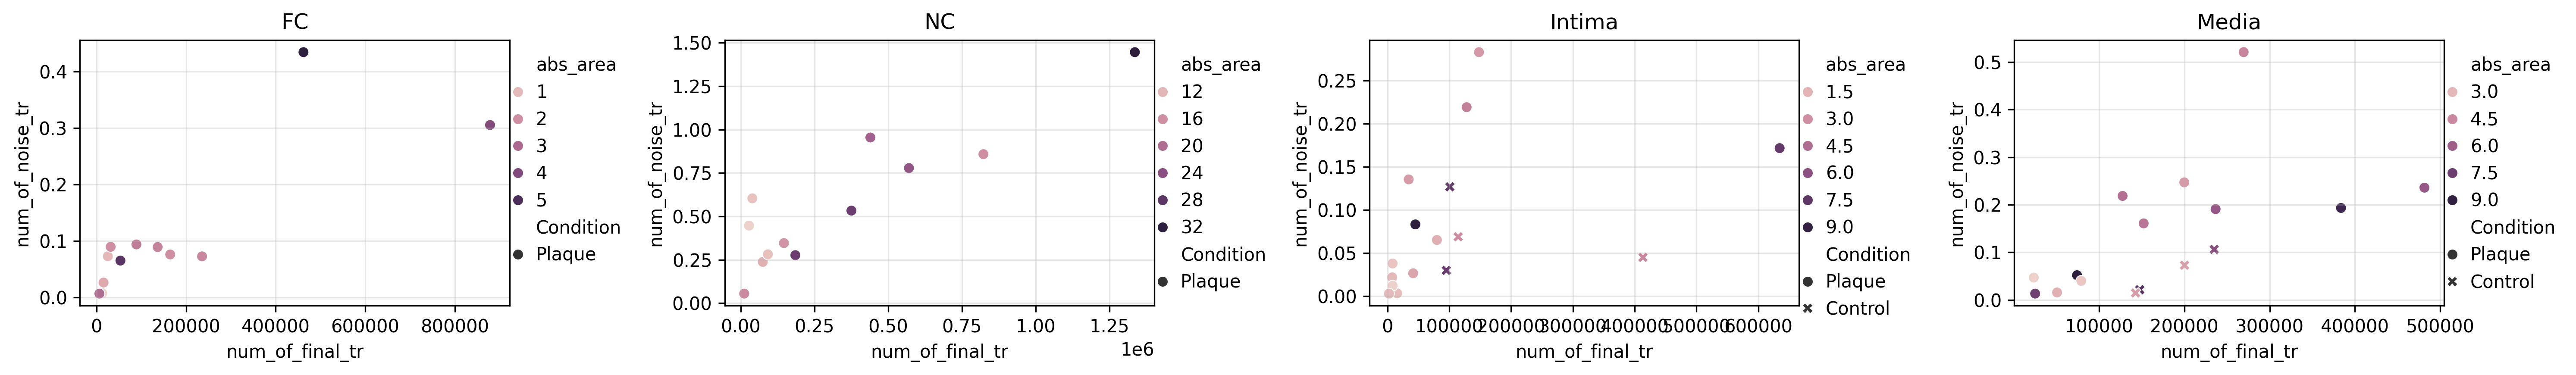

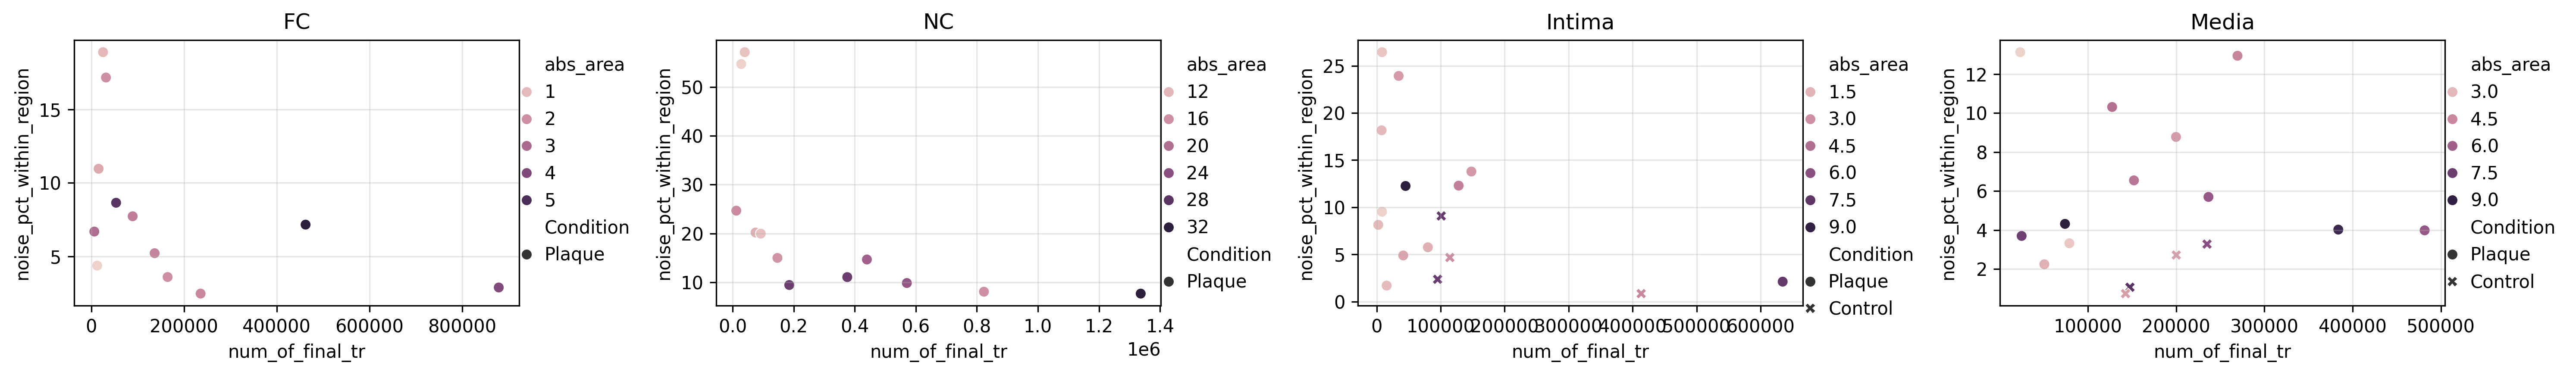

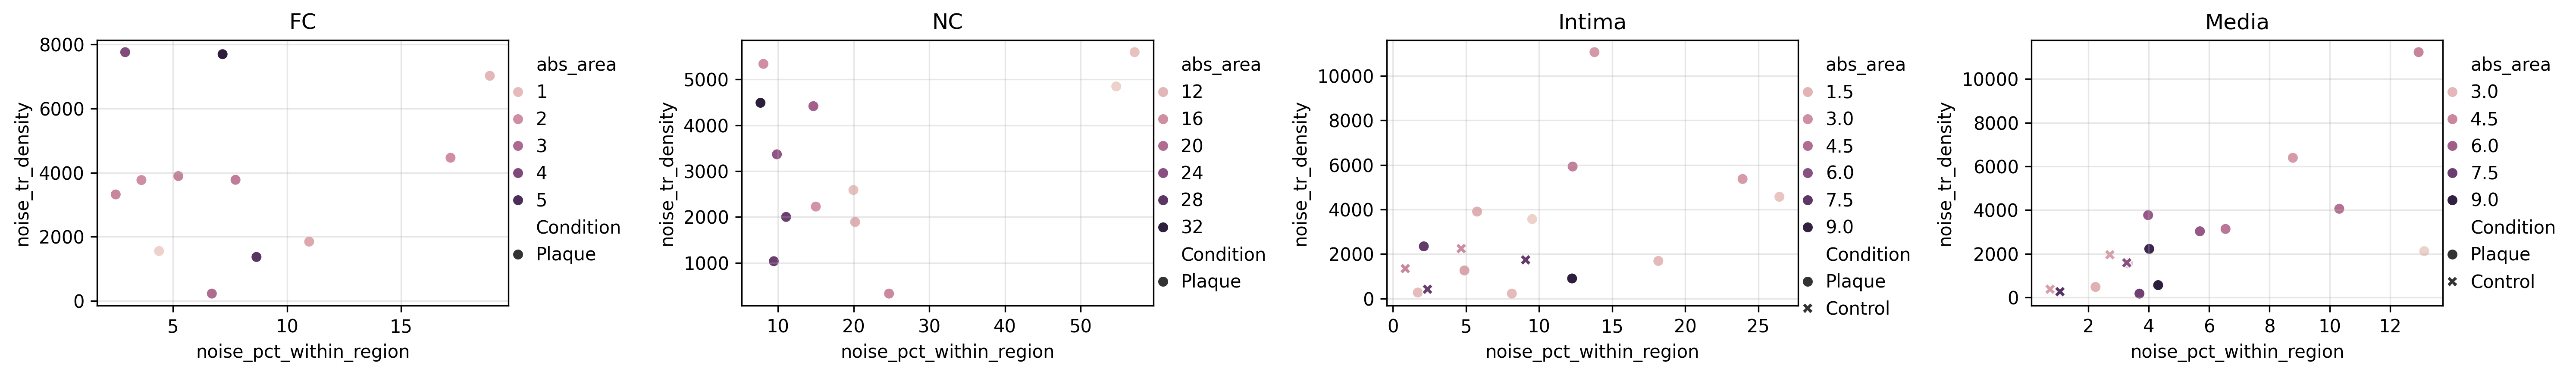

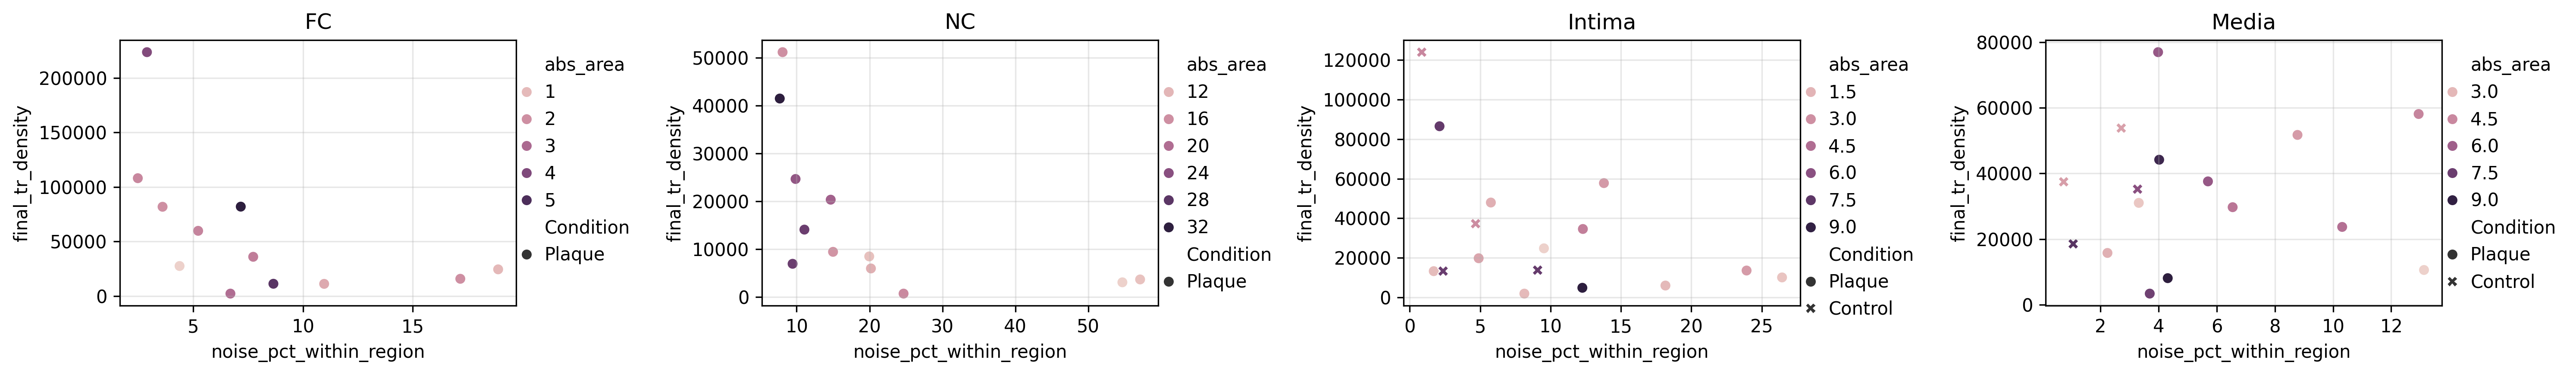

In [125]:

regions=area_noise_concat_df['region'].unique()[1:]
ncols=4
nrows=int(np.ceil(len(regions)/ncols))



p_values=[]

x_y_list=[('num_of_final_tr','num_of_noise_tr','abs_area'),
          ('num_of_final_tr','noise_pct_within_region','abs_area'),
          ('noise_pct_within_region','noise_tr_density','abs_area'),
          ('noise_pct_within_region','final_tr_density','abs_area'),
          ('abs_area','num_of_final_tr',None),
         ('abs_area','num_of_noise_tr',None),
         ('abs_area','noise_pct_within_sample',None),
         ('abs_area','noise_pct_within_region',None),
         ('norm_area','noise_pct_distr_in_region',None),
         #('num_of_final_tr','num_of_noise_tr'),
         ][:4]
for x,y,hue in x_y_list:
    fig=plt.figure(figsize=(ncols*5,nrows*3))
    for n,region in enumerate(regions):
        
        ax=fig.add_subplot(nrows,ncols,n+1)
        plot_df=area_noise_concat_df[area_noise_concat_df['region']==region]

        plot_df['noise_tr_density'] = plot_df['num_of_noise_tr'] / plot_df['abs_area']
        plot_df['final_tr_density'] = plot_df['num_of_final_tr'] / plot_df['abs_area']
        plot_df[['noise_pct_within_sample', 'noise_pct_within_region', 'true_pct_within_region']] *= 100
        plot_df[['num_of_hq_tr']] /= 10**6
        plot_df[['num_of_noise_tr']] /= 10**5

    
        #x='norm_area'
        #x='abs_area'
        #x='num_of_noise_tr'
        #x='num_of_final_tr'
        #y='num_of_hq_tr'
        #y='num_of_final_tr'
        #y='num_of_noise_tr'
        #y='noise_pct_within_region'
        #y='noise_pct_within_sample'
        #y='noise_pct_distr_in_region'
        #y='num_of_all_tr_region'
        #hue='Condition'
        #hue='abs_area'
        #hue='noise_pct_within_region'
    
        '''
        model = smf.mixedlm(f"{y} ~ {x}", plot_df, groups=plot_df["patient"])
                    
        try:
            result = model.fit(method=["powell", "lbfgs"], reml=False)
            p_value = result.pvalues.get(x_col, np.nan)  # Extract p-value for predictor
        except:
            p_value = np.nan  # If model fails, set NaN
        
        p_values.append(p_value)
    
        # Perform FDR correction
        _, fdr_corrected_pvals, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
        '''
    
        sns.scatterplot(data=plot_df,
                        x=x,
                        y=y,
                        ax=ax,
                        hue=hue,
                        #palette='viridis',
                        style='Condition',
                        #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                       )
        
        handles,labels = ax.get_legend_handles_labels()
        ax.legend(handles,labels,frameon=False,loc='upper left',bbox_to_anchor=(0.94,1),handletextpad=0.005)
        
        ax.set_title(region)
        max_val=max(ax.get_xlim()[1],ax.get_ylim()[1])
        min_val=min(ax.get_xlim()[0],ax.get_ylim()[0])
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(alpha=0.3)
        
        #ax.plot([min_val,max_val],[min_val,max_val]) #transform=ax.transAxes)
    
        plt.tight_layout()

In [ ]:

ycols=['abs_area','num_of_final_tr','num_of_noise_tr','noise_pct_within_sample',
       'noise_pct_within_region',#'norm_area','noise_pct_distr_in_region',
      ]

ncols=2
nrows=int(np.ceil(len(ycols)/ncols))

fig=plt.figure(figsize=(ncols*5,nrows*3))

p_values=[]


plot_df=area_noise_concat_df[~area_noise_concat_df['region'].isin(['Lumen'])]


for n,y_col in enumerate(ycols):

    ax=fig.add_subplot(nrows,ncols,n+1)

    #x='norm_area'
    x='region'
    #x='num_of_noise_tr'
    #y='num_of_hq_tr'
    #y='num_of_final_tr'
    #y='num_of_noise_tr'
    #y='noise_pct_within_region'
    #y='noise_pct_within_sample'
    #y='noise_pct_distr_in_region'
    #y='num_of_all_tr_region'
    hue='Condition'
    #hue='abs_area'
    #hue='noise_pct_within_region'
    y=y_col



    sns.boxplot(data=plot_df,
                    x=x,
                    y=y,
                    ax=ax,
                    hue=hue,
                    palette='viridis',
                    boxprops={'facecolor': 'none'},
                    legend=False,
                    #style='Condition',
                    #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                   )
    sns.stripplot(data=plot_df,
                    x=x,
                    y=y,
                    ax=ax,
                    hue=hue,
                    dodge=True,
                    palette='Set2',
                    linewidth=0.5,
                    #style='Condition',
                    #hue_norm=(plot_df[hue].quantile(0.05),plot_df[hue].quantile(0.95))
                   )
    
    
    handles,labels = ax.get_legend_handles_labels()
    ax.legend(handles,labels,frameon=False,
              loc='best',
              #bbox_to_anchor=(0.97,1)
              handletextpad=0.01)
    
    #ax.set_title(region)
    max_val=max(ax.get_xlim()[1],ax.get_ylim()[1])
    min_val=min(ax.get_xlim()[0],ax.get_ylim()[0])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(alpha=0.3)
    
    #ax.plot([min_val,max_val],[min_val,max_val]) #transform=ax.transAxes)
    
    plt.tight_layout()

In [ ]:
plot_df[plot_df['region']=='Lumen']

In [ ]:
img_array

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(6,6))
final_transcr=seg[(~seg['cell'].isna())&\
                                (seg['confidence']>confidence_thr)&\
                                (seg['assignment_confidence']>assignment_confidence_thr)&\
                                (seg['qv']>qv_thr)\
                                &(seg['on_sample_area']=='yes')]

im=ax.scatter(seg_not_noise['x'],seg_not_noise['y'],s=0.1,c=seg_not_noise['confidence'],cmap='Reds')
ax.invert_yaxis()
fig.colorbar(im, ax=ax)

In [ ]:
from shapely.geometry import Point, Polygon,MultiPolygon
from matplotlib import path as mpath
import shapely

## SUBSET TO NOISE TRANSCRIPTS, THAT ARE WITHIN THE AREA OF THE SAMPLE
qv_thr=20
seg_noise=seg[(seg['qv']>qv_thr)\
            #&(seg['cell'].isna())\
            #&(seg['confidence']==0.0)
            ]

for region in [*reg_area_dict][-1:]:
    print(region)
    region_polygon = reg_area_dict[region]['region_polygon']
    
    if isinstance(region_polygon,MultiPolygon):
        l=[]
        for p in region_polygon.geoms:
            region_vertices=shapely.get_coordinates(p)
            reg_path = mpath.Path(region_vertices)
            reg_mask = reg_path.contains_points(seg_noise[['y', 'x']]/10)
            l.append(reg_mask)
    
        reg_mask = np.any(np.vstack(l),axis=0)
    
    if isinstance(region_polygon,Polygon):
        region_vertices=shapely.get_coordinates(region_polygon)
        reg_path = mpath.Path(region_vertices)
        reg_mask = reg_path.contains_points(seg_noise[['y', 'x']]/10)
    
    
    seg_noise_within_area=seg_noise.loc[reg_mask,:]

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(6,6))
im=ax.scatter(seg_noise_within_area['x']/10,seg_noise_within_area['y']/10,s=0.1,c=seg_noise_within_area['confidence'],cmap='Reds',alpha=0.3)
region_vertices=shapely.get_coordinates(region_polygon)
ax.scatter(region_vertices[:,1],region_vertices[:,0],s=3,c='green',alpha=0.6)
ax.invert_yaxis()
fig.colorbar(im, ax=ax)

In [ ]:
plot_df=seg_hq_.loc[seg_hq_['gene'].isin(['CTSB','MYH11']),:]
fig,ax=plt.subplots(1,1,figsize=(6,6))
sns.kdeplot(data=plot_df,x='x',y='y',hue='gene',ax=ax,bw_adjust=0.5,cut=0,fill=True)
#ax.scatter(plot_df['x'],plot_df['y'],s=0.1,c='blue')

im=ax.scatter(seg_hq_['x'],seg_hq_['y'],s=0.1,c=seg_hq_['confidence'],cmap='Reds',alpha=0.3)
ax.invert_yaxis()
fig.colorbar(im, ax=ax)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(6,6))

im=ax.scatter(seg_hq_['x'],seg_hq_['y'],s=0.1,c=seg_hq_['confidence'],cmap='Reds')
ax.invert_yaxis()
fig.colorbar(im, ax=ax)

#plt.figure(figsize=(6,6))
#plt.imshow(img_array)


In [ ]:
a=shapely.unary_union(region_polygon)


In [ ]:
len(a.geoms)

In [ ]:
qv_thr=20
seg_hq=seg[(seg['qv']>qv_thr)\
            &(seg['cell'].isna())\
            &(seg['confidence']==0.0)
            ]
fig,ax=plt.subplots(1,1,figsize=(6,6))

im=ax.scatter(seg_hq['x'],seg_hq['y'],s=0.1,c=seg_hq['confidence'],cmap='Reds')
ax.invert_yaxis()
fig.colorbar(im, ax=ax)

plt.figure(figsize=(6,6))
plt.imshow(img_array)


In [ ]:
seg[(~seg['cell'].isna())\
        &(seg['assignment_confidence']>0.5)].shape

In [ ]:
qv_thr=20
seg_hq=seg[(seg['qv']>qv_thr)\
            &(seg['cell'].isna())\
            &(seg['confidence']>0.0)
            ]
fig,ax=plt.subplots(1,1,figsize=(6,6))

im=ax.scatter(seg_hq['x'],seg_hq['y'],s=0.1,c=seg_hq['confidence'],cmap='Reds')
fig.colorbar(im, ax=ax)


# Compare on segmentation level

### Read and concatenate segmentations files from Baysor

In [ ]:
def return_best_model_dict():
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df

    return best_model_dict


### LOAD THE PREVIOUSLY CREATED ANNDATAS OF THE BEST MODELS
## Samples of first run
panels=['Panel1','Panel2']

def return_panel_sample_names(panels):
    pat_nums=['P1','P2','P3','P4']
    conditions=['D','H']
    
    panel_sample_names_first_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    ## Samples of second run
    pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12']
    conditions=['D']
    panel_sample_names_second_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panel_sample_names=panel_sample_names_first_run + panel_sample_names_second_run

    return panel_sample_names
    

## Determine which AUC metric to use for selection of best model 
#  (to check on which to select, check 'best_model_dict's ' elements
auc_metric='high_confidence_auc'
avg_assignment_conf_thr=0.75 #0.75
scale_params=['5','10','15','5|10|15']
scale_params=['10','15']
    

adata_hq_dict={}



### ======== SET THIS TO SELECT WHICH SCALA PARAM CELL SEGMENTATIONS TO CONSIDER!!! ###
scale_param='10'# '5|10|15' #'15' #'15' #'5|10|15'
##### ======== 

seg_dict={}
for panel in ['Panel1','Panel2'][:1]:

    panel_sample_names=return_panel_sample_names([panel])
    
    seg_dict[panel]={}
    
  
    for scale_param in scale_params:
        l=[]

        print(scale_param,'\n')
        
        #for panel_sample_name in panel_sample_names[:1]:
        for panel_sample_name in large_cell_samples[:1]:
            
            print(panel_sample_name)
        
            ## Extract name of best baysor model to use for the sample
            best_model=best_model_dict[auc_metric][scale_param].loc[panel_sample_name,avg_assignment_conf_thr]
            print(best_model)
            bays_model_name='assignments_'+best_model
        
            baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,index_col=0)
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue
        
            seg_stats_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation_cell_stats.csv')
            seg_stats=pd.read_csv(seg_stats_fn)
    
            confidence_thr=0.8
            assignment_confidence_thr=0.5
            qv_thr=20

            seg[f'{scale_param}_cell_transcr']=np.nan
            
            true_mask=(~seg['cell'].isna())&\
                            (seg['confidence']>confidence_thr)&\
                            (seg['assignment_confidence']>assignment_confidence_thr)&\
                            (seg['qv']>qv_thr)
            
            seg.loc[true_mask.values,f'{scale_param}_cell_transcr']='y'
            
            adata = adata_dict_[scale_param]['Panel1']
            
            
            comm_cell_idx = list(set(seg['cell'])& set(adata.obs.index))      
            seg_mask=seg['cell'].isin(comm_cell_idx)        
            adata_cell_ids = seg.loc[seg_mask.values,'cell'].values
            

            seg[f'{scale_param}_celltype']=np.nan
            seg.loc[seg_mask.values,f'{scale_param}_celltype']= adata.obs.loc[adata_cell_ids,'final_low_level_celltype'].astype(str).values

            seg[f'{scale_param}_cell_id']=seg['cell'].values

            l.append(seg)

        seg_scale_param_merged=pd.concat(l,axis=0)
        
        seg_dict[panel][scale_param]=seg_scale_param_merged

## Merge all segmentations into ine dataframe

In [ ]:
merged_seg = pd.concat([seg_dict[panel]['10'],seg_dict[panel]['15'][['15_cell_id','15_cell_transcr','15_celltype']]],axis=1)
a=merged_seg[merged_seg['10_celltype'] == merged_seg['15_celltype']].groupby(['15_celltype','15_cell_id'],as_index=True).apply(lambda x: x['10_cell_id'].unique().shape[0])
a=a.to_frame()

In [ ]:
## Plot

In [ ]:
celltypes=a.reset_index()['15_celltype'].unique()
ncols=3
nrows=int(np.ceil(len(celltypes))/ncols)
fig=plt.figure(figsize=(ncols*4,nrows*3))

#a=a.to_frame()
a['cell_mask_area_um2']=adata_dict_['15'][panel].obs.loc[a.index.get_level_values('15_cell_id'),'cell_mask_area_um2'].values

for n,(cellt,cellt_df) in enumerate(a.groupby('15_celltype')):
    ax=fig.add_subplot(nrows,ncols,n+1)
    sns.histplot(data=cellt_df.reset_index(),x=0,hue='15_celltype',ax=ax)
    #sns.violinplot(data=cellt_df.reset_index(),y='cell_mask_area_um2',x=0,hue='15_celltype',ax=ax,cut=0)
    #ax.set_xlim(0,12)

plt.tight_layout()

In [ ]:
b=merged_seg[merged_seg['10_celltype'] != merged_seg['15_celltype']].groupby(['15_celltype','15_cell_id','10_celltype'],as_index=True).apply(lambda x: x['10_cell_id'].unique().shape[0])
b=b.to_frame()

In [ ]:
celltypes=b.reset_index()['15_celltype'].unique()
ncols=2
nrows=int(np.ceil(len(celltypes)/ncols))
fig=plt.figure(figsize=(ncols*4,nrows*3))

#a=a.to_frame()
b['cell_mask_area_um2']=adata_dict_['15'][panel].obs.loc[b.index.get_level_values('15_cell_id'),'cell_mask_area_um2'].values

for n,(cellt,cellt_df) in enumerate(b.groupby('15_celltype')):
    ax=fig.add_subplot(nrows,ncols,n+1)
    sns.histplot(data=cellt_df.reset_index(),x='10_celltype',hue='15_celltype',ax=ax)
    #sns.violinplot(data=cellt_df.reset_index(),y='cell_mask_area_um2',x=0,hue='15_celltype',ax=ax,cut=0)
    #ax.set_xlim(0,12)
    ax.tick_params(axis='x', rotation=90,labelsize=7)

plt.tight_layout()

### Correlation between cells,same celltype

In [ ]:
celltype='Mac_TREM2hi'
#celltype='Mac_HMOX1'

## Select cell IDS of the larger parameter, which has its transcripts in multiple other cells of the smalller scale_param  segmentation
#. BUT: they were assigned the same cell type
doublet_cell_ids_15=a.reset_index()[(a.reset_index()['15_celltype']==celltype)&(a.reset_index()[0]>1)]['15_cell_id'].tolist()
doublet_cell_ids_10 = merged_seg.loc[(merged_seg['15_cell_id'].isin(doublet_cell_ids_15))&\
                                     (~merged_seg['10_cell_transcr'].isna())&\
                                      (~merged_seg['15_cell_transcr'].isna())&\
                                    (~merged_seg['10_celltype'].isna()),'10_cell_id'].unique().tolist()

doublet_cell_id_table = merged_seg.loc[(merged_seg['15_cell_id'].isin(doublet_cell_ids_15))&\
                                        (~merged_seg['10_cell_transcr'].isna())&\
                                       (~merged_seg['15_cell_transcr'].isna())&\
                                      (~merged_seg['10_celltype'].isna()),['10_cell_id','15_cell_id']].drop_duplicates(subset=['10_cell_id','15_cell_id']).set_index('15_cell_id')



num_of_overlapp_transcripts = merged_seg.loc[merged_seg['15_cell_id'].isin(doublet_cell_ids_15)&\
                                      (~merged_seg['10_celltype'].isna())&\
                                      (~merged_seg['10_cell_transcr'].isna())&\
                                      (~merged_seg['15_cell_transcr'].isna())
                                            ,['10_cell_id','15_cell_id']].groupby(['10_cell_id','15_cell_id']).apply(lambda x: x.shape[0]).reset_index()#.set_index('15_cell_id')

num_of_overlapp_transcripts = pd.concat([doublet_cell_id_table.reset_index().set_index(['15_cell_id','10_cell_id']),num_of_overlapp_transcripts.set_index(['15_cell_id','10_cell_id'])],axis=1)


row_indices=[doublet_cell_ids_10.index(ind) for ind in num_of_overlapp_transcripts.index.get_level_values('10_cell_id')]
col_indices=[doublet_cell_ids_15.index(ind) for ind in num_of_overlapp_transcripts.index.get_level_values('15_cell_id')]

adata_dict_['10']['Panel1'][doublet_cell_ids_10,:].layers['raw_counts']
adata_dict_['15']['Panel1'][doublet_cell_ids_15,:].layers['raw_counts']

# Convert matrices to dense arrays if feasible (only if memory allows)
matrix1_dense = adata_dict_['10']['Panel1'][doublet_cell_ids_10,:].layers['raw_counts'].toarray()
matrix2_dense = adata_dict_['15']['Panel1'][doublet_cell_ids_15,:].layers['raw_counts'].toarray()

'''
# Standardize each cell vector in both matrices (z-score normalization)
matrix1_standardized = (matrix1_dense - matrix1_dense.mean(axis=1, keepdims=True)) / matrix1_dense.std(axis=1, keepdims=True)
matrix2_standardized = (matrix2_dense - matrix2_dense.mean(axis=1, keepdims=True)) / matrix2_dense.std(axis=1, keepdims=True)

# Compute the correlation matrix using matrix multiplication
correlation_matrix = np.dot(matrix1_standardized, matrix2_standardized.T) / matrix1_dense.shape[1]

plt.hist(correlation_matrix[row_indices,col_indices],bins=50);
'''


# Normalize each row to unit length (L2 norm)
matrix1_normalized = matrix1_dense / np.linalg.norm(matrix1_dense, axis=1, keepdims=True)
matrix2_normalized = matrix2_dense / np.linalg.norm(matrix2_dense, axis=1, keepdims=True)

# Compute the cosine similarity matrix
cosine_similarity_matrix = np.dot(matrix1_normalized, matrix2_normalized.T)0
plt.hist(cosine_similarity_matrix[row_indices,col_indices],bins=50);



## Plot individual cells with Baysor cell mask

In [ ]:
#sample_dir="20230808__140639__2311-01_Sachs_Panel1/output-XETG00050__0003370__P4_D__20230808__140759"
def return_best_model_dict():
    
    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    
    ## Load previously created avg_assign_conf_dict
    proc_dir=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor')
    fpath=os.path.join(proc_dir,'avg_assign_conf_dict.pickle')
    avg_assign_conf_dict=pickle.load(open(fpath, "rb"))
    
    ## Determine which AUC metric to use for selection of best model 
    #  (to check on which to select, check 'best_model_dict's ' elements
    
    
    best_model_dict={}
    for auc_metric in ['high_confidence_auc','high_confidence_weighted_auc'][0:1]:
        print(auc_metric) 
        best_model_dict[auc_metric]={}
        
        ## Filter for presegmentation method if desired ==> only consider baysor models with given presegm. method
        # Select from: '10x','CPc','CPn','np_segmentation', or write '' to not filter fol presegm. method
        presegmentation_method='' 
        
        for scale_param in ['5','10','15','5|10|15']:
            
            
            df=pd.DataFrame(index=[*avg_assign_conf_dict],columns=[0.7,0.75,0.8,0.85,0.9,0.95])
            for avg_assignment_conf_thr in [0.7,0.75,0.8,0.85,0.9,0.95]:
                #print('avg_assignment_conf_thr',avg_assignment_conf_thr)
                
                l=[]
                for panel_sample_name in [*avg_assign_conf_dict]:
                    auc_df=avg_assign_conf_dict[panel_sample_name]
    
                    model_filt=(auc_df['baysor_scale_param'].str.contains(rf'\b{scale_param}\b'))&\
                                (auc_df['presegmentation_method'].str.contains(presegmentation_method))
                    best_model_per_thr=(auc_df[model_filt].groupby('avg_assignment_confidence_thr').apply(lambda x: x.loc[x['high_confidence_weighted_auc']==x['high_confidence_weighted_auc'].max()]))
                    
                    best_model=panel_sample_name,best_model_per_thr.loc[avg_assignment_conf_thr:,auc_metric].reset_index()['level_1'].values[0]
                    l.append(best_model[1])
                    #print(panel_sample_name,best_model)
                df[avg_assignment_conf_thr]=l
                #print('==============')
            
            best_model_dict[auc_metric][scale_param]=df

    return best_model_dict



def return_panel_sample_names(panels):
    pat_nums=['P1','P2','P3','P4']
    conditions=['D','H']
    
    panel_sample_names_first_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    ## Samples of second run
    pat_nums=['P5','P6','P7','P8','P9','P10','P11','P12']
    conditions=['D']
    panel_sample_names_second_run=['_'.join([panel,pat_num,condition]) for panel in panels for pat_num in pat_nums for condition in conditions]
    
    panel_sample_names=panel_sample_names_first_run + panel_sample_names_second_run

    return panel_sample_names

def read_ome_tiff(slide_type,data_dir,sample_dir):
    from pyometiff import OMETIFFReader
    import tifffile as tff
    if slide_type=='focus':
        fn=os.path.join(data_dir,sample_dir,'morphology_focus.ome.tif')

    if slide_type=='mip':    
        fn=os.path.join(data_dir,sample_dir,'morphology_mip.ome.tif')

    if slide_type=='z_stack': 
        fn=os.path.join(data_dir,sample_dir,'morphology.ome.tif')
        
    reader = OMETIFFReader(fpath=fn)
    img_array,metadata,xml_metadata=reader.read()

    return img_array,metadata,xml_metadata

def load_slide_img(large_cell_samples):

    data_dir="../../xenium_data/"#processed_data/baysor_output" #cell_segmentation"
    
    ## Drop scratch folders that start with "._"
    #panel_dir=[f for f in os.listdir(data_dir) if ('Panel' in f and '._' not in f and '202312' in f)]
    panel_dir=[f for f in os.listdir(data_dir) if ('Panel' in f and '._' not in f)]
    panel_dir.sort()
    
    ## Create list of samples to loop over (as script sometimes exits due to kernel death, this cell may need to be run split between the samples)
    #  => this list controls which samples are being processed
    panels=['Panel2','Panel1']
    #samples=['P1_H','P2_H','P3_H','P4_H','P1_D','P2_D','P3_D','P4_D']
    samples=['P5_D','P7_D','P8_D','P9_D','P10_D','P11_D','P12_D'] #'P6_D'
    #samples=['P6_D'] #'P6_D'
    
    
    #panels=['Panel1']
    #samples=['P3_D']
    samples_to_loop_over=['_'.join([panel,sample]) for panel in panels for sample in samples]
    
    segmend_dict={'no_segmentation':{},
                 '10x':{'expansion_sizes':[0]},
                 'cellpose':{'expansion_sizes':[4,6,10],
                             'modes':['cyto','nucleus']}
                 }
    
    #print(panel_dir)
    for panel in panel_dir[:]:
        panel_dir=os.path.join(data_dir,panel)
    
     
        ## Loop over all samples in a batch
        for sample_name in os.listdir(panel_dir)[0:]:
            #print(sample_name)
            
            sample_dir=os.path.join(data_dir,panel,sample_name)
    
            if os.path.isdir(sample_dir): #and 'P1_D' in sample_dir:
                sample_dict={}
                
                #print(panel)
                ## Extract Panel_Sample_name as string ==> F
                #  - for the first batch of patients (P1-P4) the output directory names are the default Xenium ranger output names
                #    here the panel_sample_name can be retrieved via " '_'.join([panel.split('_')[-1],sample_name.split('__')[2]])"
                #  - For the second batch of patients (P5-P12) the "add_patient_name_to_fnames.ipynb" Notebook changes the names
                #    to a Panelx_Px_D format ==> panel_sample_name==sample_dir
                try:
                    panel_sample_name='_'.join([panel.split('_')[-1],sample_name.split('__')[2]])
                except IndexError:
                    panel_sample_name=sample_name
                #print(panel_sample_name)
                ## Check if the sample name is in the samples that should be processed => if yes process them

                #print('panel_sample_name in loading slime img',panel_sample_name)
                replacements = {'_H':'_Ctrl','_D':'_Pl'}
                for old, new in replacements.items():
                    if old in panel_sample_name:
                        panel_sample_name_ = panel_sample_name.replace(old, new)
                        #print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
                
                if panel_sample_name_ in large_cell_samples[:]:
                    #logging.info(panel_sample_name_)
                    #print(panel_sample_name_)
                    
        
                    ## Load DAPI fluorescent-stained slide image
                    # Select one slide_type ('mip'/'focus'/z_stack') file to load and 
                    slide_type='mip'
                    img_array,metadata,xml_metadata=read_ome_tiff(slide_type,data_dir,sample_dir)
                    #logging.info('Slide loaded')
                    return img_array
                
                #if panel_sample_name_ not in large_cell_samples[:]:
                #    raise ValueError(f'{panel_sample_name_} not in large_cell_samples list: {large_cell_samples}')
                    




def load_segmentation(scale_param,large_cell_samples):

    data_dir="../../xenium_data/"#processed_data/cell_segmentation"
    auc_metric='high_confidence_auc'
    avg_assignment_conf_thr=0.75 #0.75

    best_model_dict = return_best_model_dict()
    
    seg_dict={}
    for panel in ['Panel1','Panel2'][:]:
    
        panel_sample_names=return_panel_sample_names([panel])
        panel_sample_names = large_cell_samples 
        
        seg_dict[panel]={}
        
      
        l=[]

        print(scale_param,'\n')
        
        #for panel_sample_name in panel_sample_names[:1]:
        for panel_sample_name in large_cell_samples[:]:
            
            print(panel_sample_name)

                        
            replacements = {'_Ctrl':'_H','_Pl':'_D'}
            for old, new in replacements.items():
                if old in panel_sample_name:
                    panel_sample_name = panel_sample_name.replace(old, new)
                    #print('orig_sample',orig_sample,'orig_sample_',orig_sample_)
        
            ## Extract name of best baysor model to use for the sample
            best_model=best_model_dict[auc_metric][scale_param].loc[panel_sample_name,avg_assignment_conf_thr]
            print(best_model)
            bays_model_name='assignments_'+best_model
        
            baysor_out_fold=os.path.join(data_dir,'processed_data/baysor_output',panel_sample_name)
            try:
                seg_fn=os.path.join(baysor_out_fold,bays_model_name,'segmentation.csv')
                seg=pd.read_csv(seg_fn,index_col=0)
                
            except FileNotFoundError:
                print(f'{seg_fn} not found! Skipping to next model!')
                continue

            ## Load dictionary with previously extracted Baysor cell boundaries 
            proc_dir_=os.path.join(data_dir,'processed_data/true_cell_filtering/baysor',panel_sample_name,bays_model_name)
            fpath=os.path.join(proc_dir_,panel_sample_name+'.pickle')
            sample_dict = pickle.load(open(fpath, "rb"))
            
            return seg,sample_dict

In [ ]:
#largest_cell_idx_
cell_bound = seg[seg['cell'].isin(largest_cell_idx_)]

confidence_thr=0.8
assignment_confidence_thr=0.5
qv_thr=20

#cell_bound[f'{scale_param}_cell_transcr']=np.nan
    
cell_bound=cell_bound[(~cell_bound['cell'].isna())&\
                    (cell_bound['confidence']>confidence_thr)&\
                    (cell_bound['assignment_confidence']>assignment_confidence_thr)&\
                    (cell_bound['qv']>qv_thr)]
cell_bound
large_cell_samples

In [ ]:

transc_coords['gene'].unique().shape

In [ ]:
large_cell_samples

In [ ]:
adata_dict_.keys()
adata.obs['final_low_level_celltype'].astype(str).unique()

In [ ]:
cell_bound
transc_coords['gene'].value_counts().index[:5].tolist()


from matplotlib.lines import Line2D

genes=transc_coords['gene'].value_counts().index[:5].tolist()
gene_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
gene_color_mapping = {region: gene_colors(i) for i, region in enumerate(genes)}

colors=transc_coords['gene'].map(gene_color_mapping).apply(lambda x: (0.2,0.2,0.2,0.2) if x is np.nan else x)

gene_color_mapping
plt.imshow(sub_arr,cmap=reversed_map,interpolation='none')
plt.scatter(transc_coords['x_location'].astype(int).values-xmin-1,
            transc_coords['y_location'].astype(int).values-ymin-1,
           c=colors,
           s=3)

# Create legend handles manually
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_mapping[gene], markersize=10, label=gene)
    for gene in genes
]

plt.legend(handles=legend_handles,
           #title="Top 5 Genes", 
           loc='upper left',
           fontsize=8,
           markerscale=1,
          bbox_to_anchor=(-0.5,1,),
           handletextpad=0.05,

          frameon=False)

In [ ]:
panel='Panel1'
scale_param='5|10|15'
scale_param='5'
scale_param='15'
adata=adata_dict_[scale_param][panel]
celltype='Mac_TREM2hi'
#celltype='VSMC_contr'
#celltype='VSMC_modul'


celltypes=['VSMC_contr', 'VSMC_fb-like', 'Mac_ITGAXhi', 'VSMC_inflamed',
           'EC_1', 'Mac_C1Q', 'Mac_TREM2hi', 'Mac_HMOX1',
           'Inflammatory_mixed_cell', 'EC_2', 'CD8_Teff-cell', 'Mac_S100A8hi',
           'Mast-cell', 'VSMC_modul', 'Neutrophil', 'Plasma-cell']

for panel in ['Panel1','Panel2'][:1]:

    for scale_param in ['5','10','15','5|10|15'][:-1]:

        adata=adata_dict_[scale_param][panel]

        for celltype in celltypes[:]:
            
            print(panel,scale_param,celltype)
        
            #largest_cell_idx = adata_dict_[scale_param][panel].obs['cell_mask_area_um2'].sort_values(ascending=False)[:1].index
            largest_cell_idx = adata.obs.loc[adata.obs['final_low_level_celltype']==celltype,'cell_mask_area_um2'].sort_values(ascending=False)[:20].index

            if largest_cell_idx.shape==0:
                continue
                
            large_cell_samples = adata_dict_[scale_param][panel][largest_cell_idx,:].obs[['cell_mask_area_um2','original_sample']]
            
            ncols=4
            nrows=int(np.ceil(len(largest_cell_idx)/ncols))
            fig=plt.figure(figsize=(ncols*6,nrows*6))
            fig.suptitle(f'{panel} - scale_param:{scale_param} - {celltype}',fontsize=14,fontweight='bold',y=1.02)
            n=0
            
            for sampl_name,large_cell_sample_df in large_cell_samples.groupby('original_sample'):
                #print('sampl_name',sampl_name)
            
                large_cell_samples_=[sampl_name]
                
                img_array = load_slide_img(large_cell_samples_)
            
                largest_cell_idx_ = large_cell_sample_df.index.tolist()[:]
            
                seg,sample_dict = load_segmentation(scale_param,large_cell_samples_)
                
                
                for cell_id in largest_cell_idx_:
                    
                    transc_coords = seg[seg['cell'].isin([cell_id])]
            
                    confidence_thr=0.8
                    assignment_confidence_thr=0.5
                    qv_thr=20
            
                    #cell_bound[f'{scale_param}_cell_transcr']=np.nan
                        
                    transc_coords=transc_coords[(~transc_coords['cell'].isna())&\
                                        (transc_coords['confidence']>confidence_thr)&\
                                        (transc_coords['assignment_confidence']>assignment_confidence_thr)&\
                                        (transc_coords['qv']>qv_thr)]
                    
                    #cell_bound[cell_bound['cell_id']==cell_id][['vertex_x_pixel','vertex_y_pixel']]
                    cell_bound=sample_dict['cell_bound'][sample_dict['cell_bound']['cell_id']==cell_id]
                    
                    transc_coords['x_location'] = (transc_coords['x_location']/transc_coords['pixel_width'].values).astype(int)
                    transc_coords['y_location'] = (transc_coords['y_location']/transc_coords['pixel_width'].values).astype(int)
            
                    xmin=cell_bound['vertex_x_pixel'].astype(int).min()
                    xmax=cell_bound['vertex_x_pixel'].astype(int).max()
                    ymin=cell_bound['vertex_y_pixel'].astype(int).min()
                    ymax=cell_bound['vertex_y_pixel'].astype(int).max()
                    
                    #xmin=transc_coords['x_location']
                    #xmax=transc_coords['x_location']
                    #ymin=transc_coords['y_location'].min()
                    #ymax=transc_coords['y_location'].max()
            
             
                    #print(cell_id,xmax,xmin,ymin,ymax)
                    sub_arr=img_array[ymin:ymax,xmin:xmax].copy()

                    ## add colors to pixels where transcirpts are located
                    #sub_arr[transc_coords['y_location'].astype(int).values-ymin-1,transc_coords['x_location'].astype(int).values-xmin-1]=np.max(sub_arr)

                
            
                    from mpl_toolkits.axes_grid1 import make_axes_locatable
            
                    orig_map=plt.cm.get_cmap('RdYlBu') 
                    #orig_map=plt.cm.get_cmap('viridis') 
                    reversed_map = orig_map.reversed() 
                    
                    ax=fig.add_subplot(nrows,ncols,n+1)

                    ## Show DAPI intensities
                    img=ax.imshow(sub_arr,cmap=reversed_map,interpolation='none')


                    ## Plot transcripts with colors
                    top_n_genes=10
                    genes=transc_coords['gene'].value_counts().index[:top_n_genes].tolist()
                    gene_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                    gene_color_mapping = {region: gene_colors(i) for i, region in enumerate(genes)}
                    
                    colors=transc_coords['gene'].map(gene_color_mapping).apply(lambda x: (0.8,0.8,0.8,0.1) if x is np.nan else x)
                    
                    gene_color_mapping
                    ax.scatter(transc_coords['x_location'].astype(int).values-xmin-1,
                                transc_coords['y_location'].astype(int).values-ymin-1,
                               c=colors,
                               edgecolor='black',
                               linewidths=0.1,
                               s=6)
                    
                    # Create legend handles manually
                    legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_mapping[gene], markersize=10, label=gene)
                        for gene in genes]
                    
                    ax.legend(handles=legend_handles,
                               title=f"Top {top_n_genes} Genes", 
                               loc='upper left',
                               fontsize=8,
                               markerscale=1,
                              bbox_to_anchor=(-0.3,1.1,),
                               handletextpad=0.05,
                    
                              frameon=False)
            
                    adata_dict_[scale_param][panel][cell_id,:].obs[['cell_mask_area_um2','original_sample']]
                    cell_size=np.round(adata_dict_[scale_param][panel][cell_id,:].obs['cell_mask_area_um2'].values[0])
                    cellt=adata_dict_[scale_param][panel][cell_id,:].obs['final_low_level_celltype'].values[0]
                    ax.set_title(f'ID:{cell_id}\nSize:{cell_size} um2')
            
                    # Create an AxesDivider and add a colorbar of matching height
                    divider = make_axes_locatable(ax)
                    cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust `size` and `pad` as needed
                    cbar=plt.colorbar(img, cax=cax)
                    cbar.set_label("DAPI intensity", fontsize=12) 
            
                    ## PLot OCNVEX HULL around the transripts
                    from scipy.spatial import ConvexHull
            
            
                    
                    # Assuming `cell_bound` contains 'x_location' and 'y_location' as arrays or lists
                    x_coords = cell_bound['vertex_x_pixel']-xmin-1
                    y_coords = cell_bound['vertex_y_pixel']-ymin-1
                    
                    # Stack coordinates into an array for ConvexHull computation
                    points = np.vstack((x_coords, y_coords)).T
                    
                    # Compute the convex hull
                    hull = ConvexHull(points)
            
                    hull_points = points[hull.vertices]
                    hull_points = np.vstack([hull_points, hull_points[0]])
                    
                    # Fill the convex hull area with transparency
                    ax.fill(hull_points[:, 0], hull_points[:, 1], color='white', alpha=0.1)
                    
                    # Optionally, plot the boundary of the hull for better visibility
                    ax.plot(hull_points[:, 0], hull_points[:, 1], 'w-', lw=1,alpha=0.6)
                    ## Plot the original transcript points
                   # ax.plot(transc_coords['x_location']-xmin, transc_coords['y_location']-ymin, 'bo', markersize=0.5,alpha=0.3)
            
                    n=n+1
            plt.tight_layout()
            fig.subplots_adjust(hspace=0.1) 
            
            ## SAvefig    
            os.makedirs(os.path.join(proc_dir,'xenium_plots','baysor_individual_cells'),exist_ok=True)
            fn=os.path.join(proc_dir,'xenium_plots','baysor_individual_cells',f'{panel}_{scale_param}_{celltype}_baysor_cell_mask.png')
            
            #plt.subplots_adjust(top=0.9)
            plt.savefig(fn, bbox_inches='tight',dpi=300)
            plt.close()
                    
            #plt.show()

In [ ]:
img_array


In [ ]:
merged_seg_eq=merged_seg[merged_seg['10_celltype'] == merged_seg['15_celltype']]

In [ ]:
for scale_param in scale_params:
    print('scale_param:',scale_param)
    final_cell_shape = seg_dict[panel][scale_param].loc[~seg_dict[panel][scale_param][f'{scale_param}_celltype'].isna(),f'{scale_param}_cell_id'].unique().shape
    print('num of cells in final data:',final_cell_shape)


In [ ]:
merged_seg = pd.concat([seg_dict[panel]['10'],seg_dict[panel]['15'][['15_cell_id','15_cell_transcr','15_celltype']]],axis=1)
a=merged_seg[merged_seg['10_celltype'] == merged_seg['15_celltype']].groupby(['15_celltype','15_cell_id'],as_index=True).apply(lambda x: x['10_cell_id'].unique().shape[0])
a=a.to_frame()

### Correlation between cells,same celltype

In [ ]:
celltype='Mac_TREM2hi'
#celltype='Mac_HMOX1'

## Select cell IDS of the larger parameter, which has its transcripts in multiple other cells of the smalller scale_param  segmentation
#. BUT: they were assigned the same cell type
doublet_cell_ids_15=a.reset_index()[(a.reset_index()['15_celltype']==celltype)&(a.reset_index()[0]>1)]['15_cell_id'].tolist()
doublet_cell_ids_10 = merged_seg.loc[(merged_seg['15_cell_id'].isin(doublet_cell_ids_15))&\
                                     (~merged_seg['10_cell_transcr'].isna())&\
                                      (~merged_seg['15_cell_transcr'].isna())&\
                                    (~merged_seg['10_celltype'].isna()),'10_cell_id'].unique().tolist()

doublet_cell_id_table = merged_seg.loc[(merged_seg['15_cell_id'].isin(doublet_cell_ids_15))&\
                                        (~merged_seg['10_cell_transcr'].isna())&\
                                       (~merged_seg['15_cell_transcr'].isna())&\
                                      (~merged_seg['10_celltype'].isna()),['10_cell_id','15_cell_id']].drop_duplicates(subset=['10_cell_id','15_cell_id']).set_index('15_cell_id')



num_of_overlapp_transcripts = merged_seg.loc[merged_seg['15_cell_id'].isin(doublet_cell_ids_15)&\
                                      (~merged_seg['10_celltype'].isna())&\
                                      (~merged_seg['10_cell_transcr'].isna())&\
                                      (~merged_seg['15_cell_transcr'].isna())
                                            ,['10_cell_id','15_cell_id']].groupby(['10_cell_id','15_cell_id']).apply(lambda x: x.shape[0]).reset_index()#.set_index('15_cell_id')

num_of_overlapp_transcripts = pd.concat([doublet_cell_id_table.reset_index().set_index(['15_cell_id','10_cell_id']),num_of_overlapp_transcripts.set_index(['15_cell_id','10_cell_id'])],axis=1)


row_indices=[doublet_cell_ids_10.index(ind) for ind in num_of_overlapp_transcripts.index.get_level_values('10_cell_id')]
col_indices=[doublet_cell_ids_15.index(ind) for ind in num_of_overlapp_transcripts.index.get_level_values('15_cell_id')]

adata_dict_['10']['Panel1'][doublet_cell_ids_10,:].layers['raw_counts']
adata_dict_['15']['Panel1'][doublet_cell_ids_15,:].layers['raw_counts']

# Convert matrices to dense arrays if feasible (only if memory allows)
matrix1_dense = adata_dict_['10']['Panel1'][doublet_cell_ids_10,:].layers['raw_counts'].toarray()
matrix2_dense = adata_dict_['15']['Panel1'][doublet_cell_ids_15,:].layers['raw_counts'].toarray()

'''
# Standardize each cell vector in both matrices (z-score normalization)
matrix1_standardized = (matrix1_dense - matrix1_dense.mean(axis=1, keepdims=True)) / matrix1_dense.std(axis=1, keepdims=True)
matrix2_standardized = (matrix2_dense - matrix2_dense.mean(axis=1, keepdims=True)) / matrix2_dense.std(axis=1, keepdims=True)

# Compute the correlation matrix using matrix multiplication
correlation_matrix = np.dot(matrix1_standardized, matrix2_standardized.T) / matrix1_dense.shape[1]

plt.hist(correlation_matrix[row_indices,col_indices],bins=50);
'''


# Normalize each row to unit length (L2 norm)
matrix1_normalized = matrix1_dense / np.linalg.norm(matrix1_dense, axis=1, keepdims=True)
matrix2_normalized = matrix2_dense / np.linalg.norm(matrix2_dense, axis=1, keepdims=True)

# Compute the cosine similarity matrix
cosine_similarity_matrix = np.dot(matrix1_normalized, matrix2_normalized.T)0
plt.hist(cosine_similarity_matrix[row_indices,col_indices],bins=50);


In [ ]:
adata

In [ ]:
num_of_overlapp_transcripts[0].hist(bins=50)

In [ ]:
mask = np.logical_and(num_of_overlapp_transcripts[0]<10000,num_of_overlapp_transcripts[0]>0)

plt.scatter(num_of_overlapp_transcripts[0][mask.values],\
            cosine_similarity_matrix[row_indices,col_indices][mask.values],s=1);
#plt.xscale('log')
plt.grid(None)

In [ ]:
celltypes=a.reset_index()['15_celltype'].unique()
ncols=3
nrows=int(np.ceil(len(celltypes))/ncols)
fig=plt.figure(figsize=(ncols*4,nrows*3))

#a=a.to_frame()
a['cell_mask_area_um2']=adata_dict_['15'][panel].obs.loc[a.index.get_level_values('15_cell_id'),'cell_mask_area_um2'].values

for n,(cellt,cellt_df) in enumerate(a.groupby('15_celltype')):
    ax=fig.add_subplot(nrows,ncols,n+1)
    sns.histplot(data=cellt_df.reset_index(),x=0,hue='15_celltype',ax=ax)
    #sns.violinplot(data=cellt_df.reset_index(),y='cell_mask_area_um2',x=0,hue='15_celltype',ax=ax,cut=0)
    #ax.set_xlim(0,12)

plt.tight_layout()

In [ ]:
b=merged_seg[merged_seg['10_celltype'] != merged_seg['15_celltype']].groupby(['15_celltype','15_cell_id','10_celltype'],as_index=True).apply(lambda x: x['10_cell_id'].unique().shape[0])
b=b.to_frame()

In [ ]:
b

In [ ]:
len(celltypes)/ncols

In [ ]:
celltypes=b.reset_index()['15_celltype'].unique()
ncols=2
nrows=int(np.ceil(len(celltypes)/ncols))
fig=plt.figure(figsize=(ncols*4,nrows*3))

#a=a.to_frame()
b['cell_mask_area_um2']=adata_dict_['15'][panel].obs.loc[b.index.get_level_values('15_cell_id'),'cell_mask_area_um2'].values

for n,(cellt,cellt_df) in enumerate(b.groupby('15_celltype')):
    ax=fig.add_subplot(nrows,ncols,n+1)
    sns.histplot(data=cellt_df.reset_index(),x='10_celltype',hue='15_celltype',ax=ax)
    #sns.violinplot(data=cellt_df.reset_index(),y='cell_mask_area_um2',x=0,hue='15_celltype',ax=ax,cut=0)
    #ax.set_xlim(0,12)
    ax.tick_params(axis='x', rotation=90,labelsize=7)

plt.tight_layout()

In [ ]:
for n,(cellt,cellt_df) in enumerate(b.groupby('15_celltype')):
    print(n)

In [ ]:
nrows